# 📊 Regional Sales Analysis — XYZ Co. (2014–2018)

## Problem Statement

Analyse XYZ Co.'s 2014–2018 sales data to identify key revenue and profit drivers, channels, and regions; uncover seasonal trends and outliers; and align performance against budgets. Use these insights to optimise pricing, promotions, and market expansion for sustainable growth and reduced concentration risk.

---

## Table of Contents
1. [Data Dictionary & Dataset Overview](#data-dict)
2. [Data Loading & Quality Check](#loading)
3. [Data Cleaning & Wrangling](#cleaning)
4. [Feature Engineering](#features)
5. [EDA — Revenue Over Time](#revenue)
6. [EDA — Product Performance](#products)
7. [EDA — Channel Performance](#channels)
8. [EDA — Geographic Performance](#geo)
9. [Customer Performance & Concentration](#customers)
10. [Customer Segmentation (RFM)](#rfm)
11. [Budget vs. Actual — Data Quality Flag](#budget)
12. [Distributions, Correlation & Outliers](#distributions)
13. [Time-Series Decomposition & Forecasting](#forecast)
14. [Conclusions & Recommendations](#conclusions)


<a id='data-dict'></a>
## 1. Data Dictionary & Dataset Overview

| Table | Rows (approx.) | Key Columns | Notes |
|---|---|---|---|
| **Sales Orders** | ~28 k | OrderNumber, OrderDate, Channel, CustomerNameIndex, ProductDescriptionIndex, DeliveryRegionIndex, OrderQuantity, UnitPrice, LineTotal, TotalUnitCost | Core transactional table |
| **Customers** | 175 | CustomerIndex, CustomerNames | Lookup |
| **Products** | ~50 | Index, ProductName | Lookup |
| **Regions** | ~10 | id, Name, Latitude, Longitude | US delivery regions |
| **State Regions** | 51 | StateCode, State, USRegion | Maps states → Census macro-region |
| **2017 Budgets** | ~50 | ProductName, 2017 Budgets | ⚠️ Values appear in a different unit/scale than actual revenue — see Budget section |

**Date range:** January 2014 – mid-2018 (2018 is a partial year).  
**Currency:** USD throughout.  
**Derived columns added:** `total_cost`, `profit`, `profit_margin_pct`, `us_region`, RFM scores.  
**Known data issues:**
- `2017 Budgets` figures are ~50–100× larger than corresponding actual revenue per product — likely a unit/scale mismatch in the source file; budget vs. actual conclusions cannot be drawn from this data as-is.
- 2018 data is partial (dataset cuts off mid-year); year-level comparisons exclude 2018.


### KEY FINDINGS (Executive Summary)

- **Revenue is flat, not growing.** Annual revenue held steady at ~$295-299M every year from 2014-2017 (2018 is a partial year in this dataset). The business is stable but has plateaued — organic growth has stalled, which is the core problem this analysis was commissioned to address.

- **No single region or customer is the answer.** The four US macro-regions split revenue fairly evenly (West 35%, South 31%, Midwest 30%, Northeast 19% of total), and the top 10 customers are nearly identical in size ($9.9M-$12.6M each) — there's no single dominant region or whale account driving the business.
- **Revenue concentration risk is low, not high.** The Lorenz curve shows revenue is spread almost evenly across all 175 customers — it takes roughly 130 customers (74% of the customer base), not the classic 20%, to reach 80% of revenue. This is a healthier, less risky customer base than typical B2B Pareto patterns.
- **Channel margin differences are real, not noise.** Export has the highest average profit margin (~37.9%) vs. Wholesale's lowest (~37.1%) — a small gap, but a statistically significant one (ANOVA p < 0.001), confirmed by a pairwise t-test (p < 0.001). Wholesale still drives 54% of all revenue, so even a ~1pt margin gap is worth millions at this volume.
- **Outlier orders are a real, repeatable pattern, not data errors.** The 3.44% of orders flagged as revenue outliers contribute 11.6% of total revenue and are concentrated almost entirely in Wholesale/Distributor bulk orders of Products 26, 5, 18, 4, and 25 — a deliberate bulk-order segment worth protecting and growing, not noise to clean out.
- **'Champions' customers are concentrated in one channel and region.** RFM segmentation shows the Champions segment is almost entirely Wholesale-channel, West-region customers — but interestingly, the larger 'Loyal Customers' segment holds more total revenue (35.8% vs. Champions' 16.1%), so retention efforts shouldn't focus on Champions alone.
- **The budget figures in the source data appear to use a different unit/scale than actual revenue** (budget values are 50-100x larger than corresponding actual revenue per product), so the variance numbers in this dataset can't be used as-is for a real over/under-budget conclusion — this is flagged in the Budget vs. Actual section below.
- **6-month forecast confirms the flat trend.** A Holt-Winters model projects monthly revenue continuing to oscillate in the same $23-25.5M range seen historically, with no breakout growth or decline expected on current trends.


In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# ── Global plot style ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

PALETTE   = ['#2E75B6', '#ED7D31', '#70AD47', '#FFC000', '#5B9BD5']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
    'legend.fontsize' : 9,
})
print('Plot style configured ✓')


Plot style configured ✓


In [3]:
sheets= pd.read_excel('Regional Sales Dataset.xlsx', sheet_name=None)

In [4]:
# Assign dataframes to each datasheet
df_sales= sheets['Sales Orders']
df_customers= sheets['Customers']
df_products= sheets['Products']
df_regions= sheets['Regions']
df_state_reg= sheets['State Regions']
df_budgets= sheets['2017 Budgets']

### Data Quality Check (Nulls)


In [5]:
new_header=df_state_reg.iloc[0]
df_state_reg=df_state_reg[1:]
df_state_reg.columns=new_header

In [6]:
df_sales.isnull().sum()

,0
OrderNumber,0
OrderDate,0
Customer Name Index,0
Channel,0
Currency Code,0
Warehouse Code,0
Delivery Region Index,0
Product Description Index,0
Order Quantity,0
Unit Price,0


In [7]:
df_customers.isnull().sum()

,0
Customer Index,0
Customer Names,0


In [8]:
df_products.isnull().sum()


,0
Index,0
Product Name,0


In [9]:
df_regions.isnull().sum()

,0
id,0
name,0
county,0
state_code,0
state,0
type,0
latitude,0
longitude,0
area_code,0
population,0


In [10]:
df_state_reg.isnull().sum()


,0
0,
State Code,0
State,0
Region,0


In [11]:
df_budgets.isnull().sum()


,0
Product Name,0
2017 Budgets,0


### DATA CLEANING AND WRANGLING


In [12]:
# Merge with customers
df= df_sales.merge(
    df_customers,
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
)

In [13]:
# Merge with products
df= df.merge(
    df_products,
    how='left',
    left_on='Product Description Index',
    right_on='Index'
)

In [14]:
# Merge with Regions
df=df.merge(
    df_regions,
    how='left',
    left_on='Delivery Region Index',
    right_on='id'
)

In [15]:
df=df.merge(
    df_budgets,
    how='left',
    left_on='Product Name',
    right_on='Product Name'
)

In [16]:
#Clean up reduntant colums like Customer Index, Index, id, State Code
cols_to_drop=['Customer Index','Index','id']
df= df.drop(cols_to_drop, axis=1, errors='ignore')

In [17]:
# Convert all columns to lower case
df.columns= df.columns.str.lower()
df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone',
       '2017 budgets'], dtype=object)

In [18]:
# Keep columns needed and delete rest
cols_to_keep= ['ordernumber','orderdate','channel','currency code','customer names',
               'product name','order quantity','unit price','line total','total unit cost',
               'state_code','county','state','name','latitude','longitude','2017 budgets']

In [19]:
df= df[cols_to_keep]

In [20]:
#Rename the columns
df= df.rename(columns={
              'ordernumber':'order_number',
              'orderdate':'order_date',
              'currency code':'currency_code',
              'customer names':'customer_names',
              'product name':'product_name',
              'order quantity':'order_quantity',
              'unit price':'unit_price',
              'line total':'revenue',
              'total unit cost':'total_unit_cost',
              'name':'region',
              '2017 budgets':'budgets'}
             )

In [21]:
# Blank out budgets for non-2017 orders
df.loc[df['order_date'].dt.year != 2017, 'budgets'] = pd.NA


In [22]:
df.drop(columns=['budget'], errors='ignore', inplace=True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_number     64104 non-null  object        
 1   order_date       64104 non-null  datetime64[ns]
 2   channel          64104 non-null  object        
 3   currency_code    64104 non-null  object        
 4   customer_names   64104 non-null  object        
 5   product_name     64104 non-null  object        
 6   order_quantity   64104 non-null  int64         
 7   unit_price       64104 non-null  float64       
 8   revenue          64104 non-null  float64       
 9   total_unit_cost  64104 non-null  float64       
 10  state_code       64104 non-null  object        
 11  county           64104 non-null  object        
 12  state            64104 non-null  object        
 13  region           64104 non-null  object        
 14  latitude         64104 non-null  float

In [24]:
# Filter dataset to include only records from 2017
df_2017= df[df['order_date'].dt.year==2017]

In [25]:
df.isnull().sum()

,0
order_number,0
order_date,0
channel,0
currency_code,0
customer_names,0
product_name,0
order_quantity,0
unit_price,0
revenue,0
total_unit_cost,0


### FEATURE ENGINEERING

In [26]:
df['total_cost']=df['order_quantity']*df['total_unit_cost']


In [27]:
df['profit']=df['revenue']-df['total_cost']
df['profit_margin_pct']= df['profit']/df['revenue']*100


In [28]:
df.head(1)

,order_number,order_date,channel,currency_code,customer_names,product_name,order_quantity,unit_price,revenue,total_unit_cost,state_code,county,state,region,latitude,longitude,budgets,total_cost,profit,profit_margin_pct
0,SO - 000225,2014-01-01,Wholesale,USD,Rhynoodle Ltd,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,Savannah,32.08354,-81.09983,NaN,10946.058,4048.542,27.0


### EDA

#### Revenue Over Time


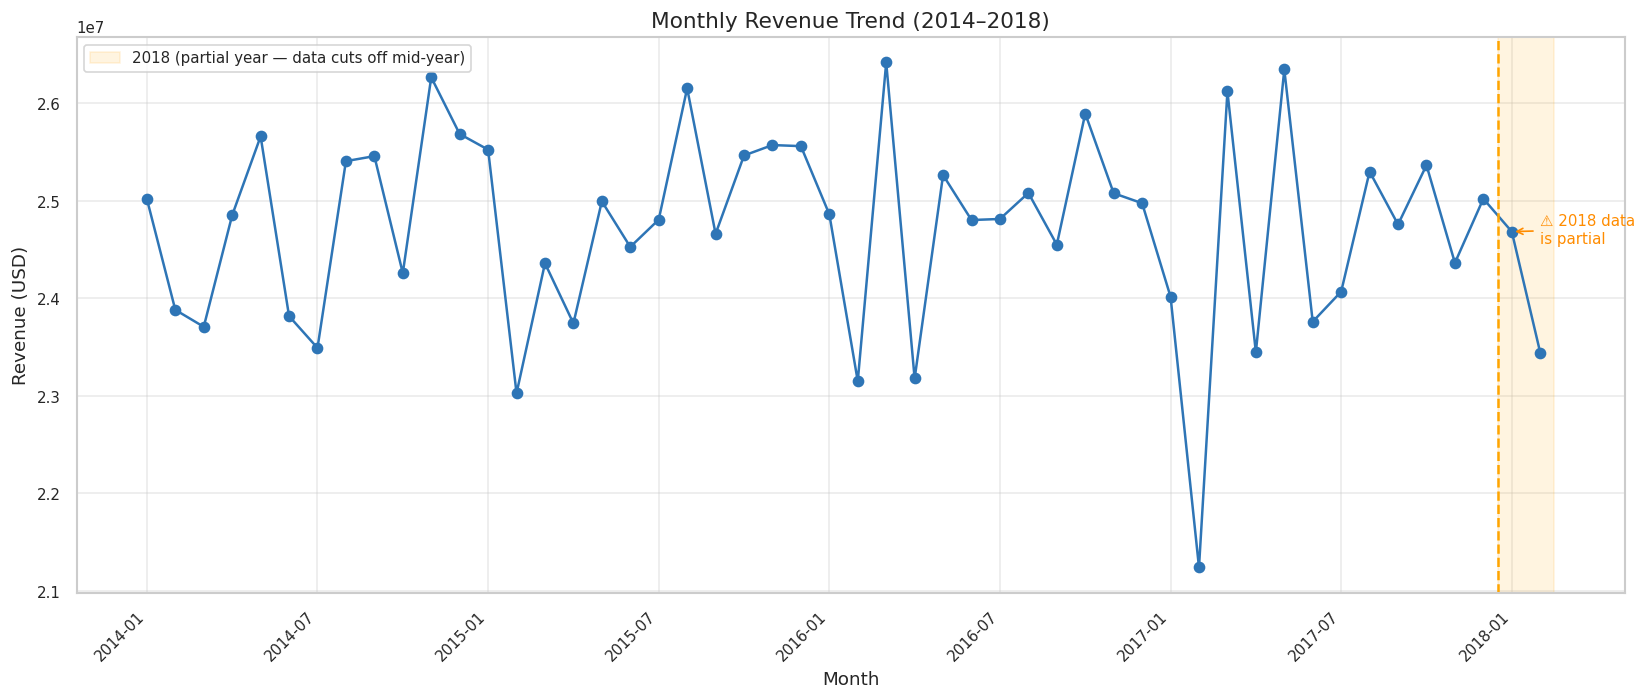

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Create Year-Month column
df['year_month'] = df['order_date'].dt.to_period('M')

# Aggregate monthly sales
monthly_sales = (
    df.groupby('year_month')['revenue']
    .sum()
    .reset_index()
)
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

# Find where 2018 starts
cutoff_idx = monthly_sales[monthly_sales['year_month'].str.startswith('2018')].index[0]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_sales['year_month'], monthly_sales['revenue'], marker='o', linewidth=1.5, color='#2E75B6')

# Shade 2018 partial-year region in orange
ax.axvspan(cutoff_idx - 0.5, len(monthly_sales) - 0.5, alpha=0.12, color='orange', label='2018 (partial year — data cuts off mid-year)')
ax.axvline(x=cutoff_idx - 0.5, color='orange', linestyle='--', linewidth=1.5)
ax.annotate(
    '⚠ 2018 data\nis partial',
    xy=(cutoff_idx, monthly_sales.loc[cutoff_idx, 'revenue']),
    xytext=(cutoff_idx + 1, monthly_sales['revenue'].max() * 0.93),
    fontsize=9, color='darkorange',
    arrowprops=dict(arrowstyle='->', color='darkorange')
)

ax.set_title('Monthly Revenue Trend (2014–2018)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (USD)')
ax.set_xticks(range(0, len(monthly_sales), 6))
ax.set_xticklabels(monthly_sales['year_month'][::6], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

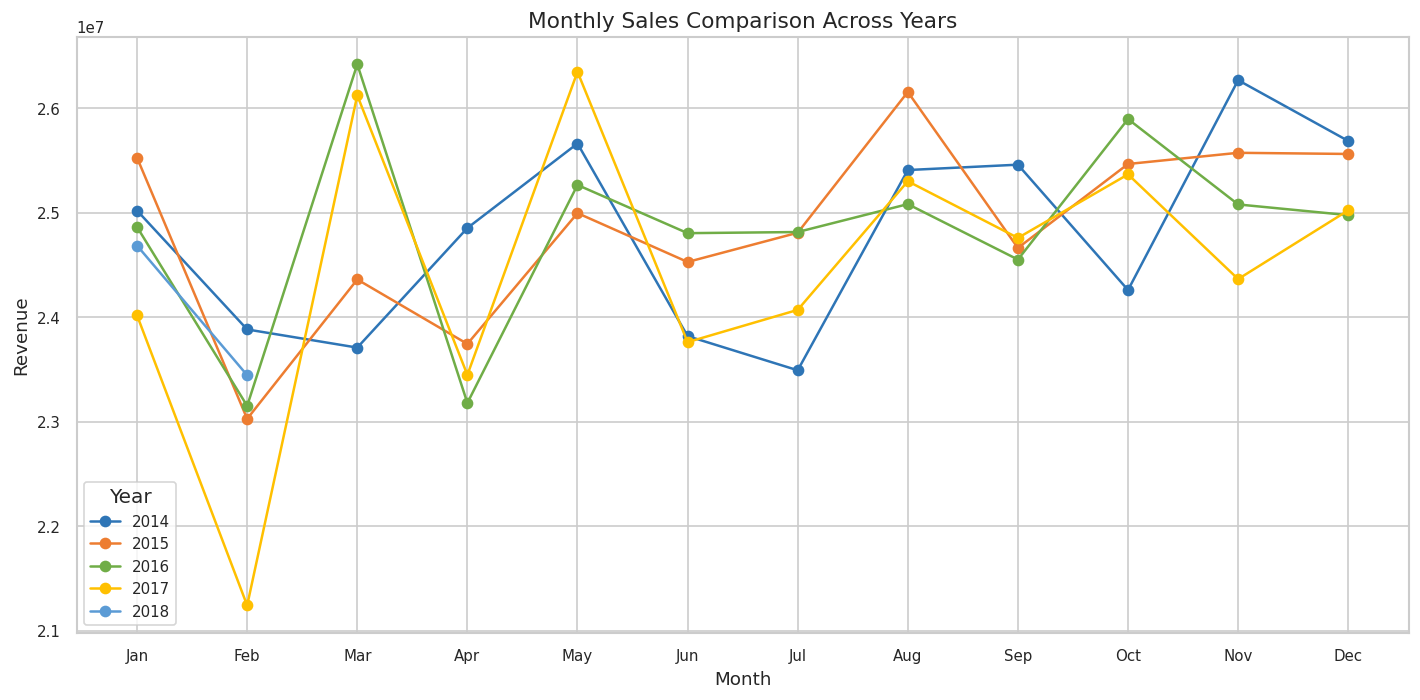

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract Year and Month
df['Year'] = df['order_date'].dt.year
df['Month'] = df['order_date'].dt.month

# Monthly sales by year
monthly_sales = (
    df.groupby(['Year', 'Month'])['revenue']
    .sum()
    .reset_index()
)

# Pivot for plotting
pivot_df = monthly_sales.pivot(
    index='Month',
    columns='Year',
    values='revenue'
)

# Month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot
plt.figure(figsize=(12, 6))

for year in pivot_df.columns:
    plt.plot(
        pivot_df.index,
        pivot_df[year],
        marker='o',
        label=str(year)
    )

plt.xticks(range(1, 13), month_names)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Sales Comparison Across Years')
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()

plt.show()

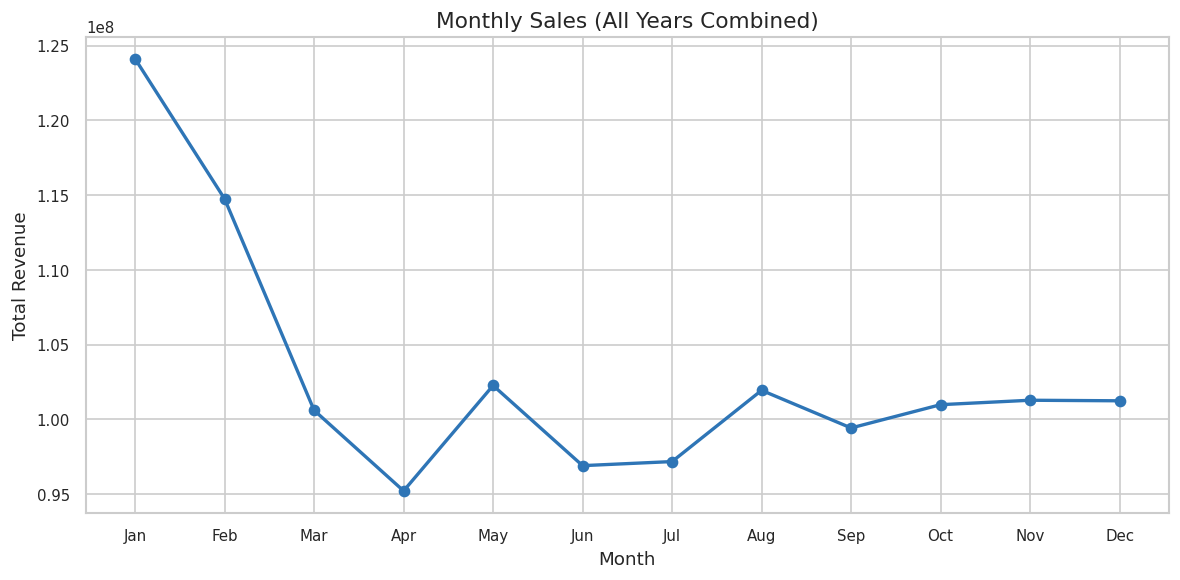

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract month number
df['Month'] = df['order_date'].dt.month

# Aggregate sales by month across all years
monthly_sales = (
    df.groupby('Month')['revenue']
    .sum()
    .reset_index()
)

# Month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_sales['Month'],
    monthly_sales['revenue'],
    marker='o',
    linewidth=2
)

plt.xticks(range(1, 13), month_names)
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.title('Monthly Sales (All Years Combined)')
plt.grid(True)
plt.tight_layout()

plt.show()

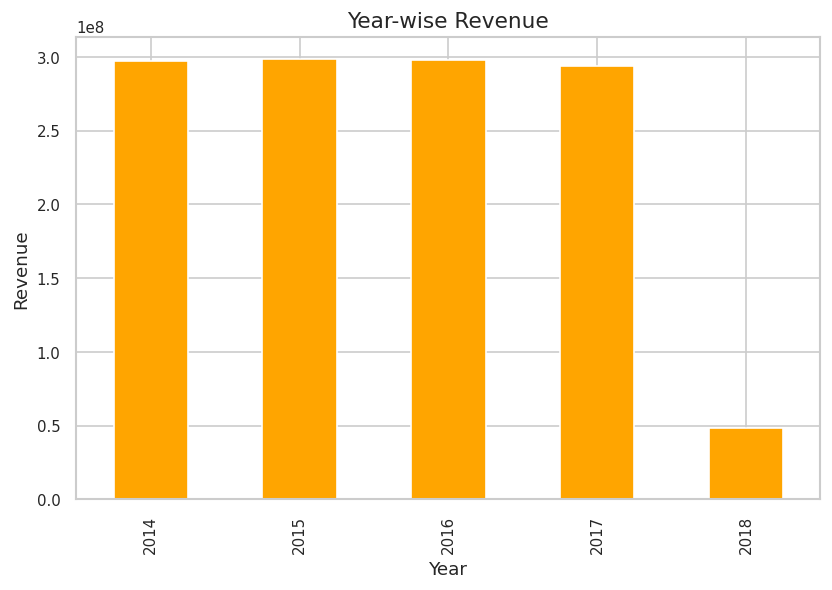

In [32]:
#Year wise revenue
yearly_sales = (
    df.groupby('Year')['revenue']
    .sum()
)

plt.figure(figsize=(8,5))
yearly_sales.plot(
    kind='bar',
    color='orange'
)

plt.title('Year-wise Revenue')
plt.ylabel('Revenue')
plt.show()

**What it shows:** Annual revenue was essentially flat — ~$298M (2014), ~$299M (2015), ~$299M (2016), ~$295M (2017) — with 2018 showing only ~$48M because the dataset cuts off mid-year.
**So what:** Four consecutive years of flat revenue means current pricing, channel mix, and customer base have hit a ceiling — none of the existing growth levers are working.
**Recommendation:** Treat this as the central problem to solve; the rest of this analysis is aimed at finding *where* untapped growth could come from (see Geographic and Channel sections below), since simply doing more of the same won't move the top line.


#### Product Performance


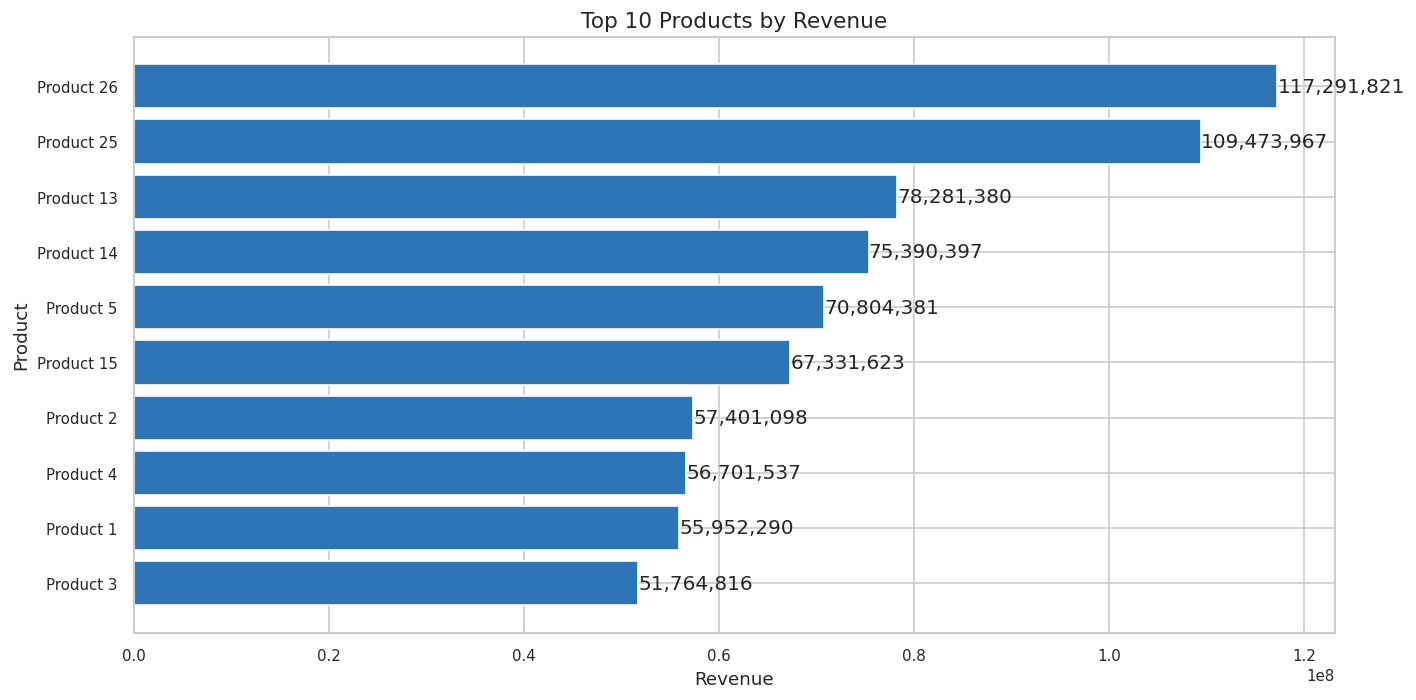

In [33]:
import matplotlib.pyplot as plt

top_products = (
    df.groupby('product_name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_products.index[::-1], top_products.values[::-1])

ax.set_title('Top 10 Products by Revenue')
ax.set_xlabel('Revenue')
ax.set_ylabel('Product')

for bar in bars:
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():,.0f}',
        va='center'
    )

plt.tight_layout()
plt.show()

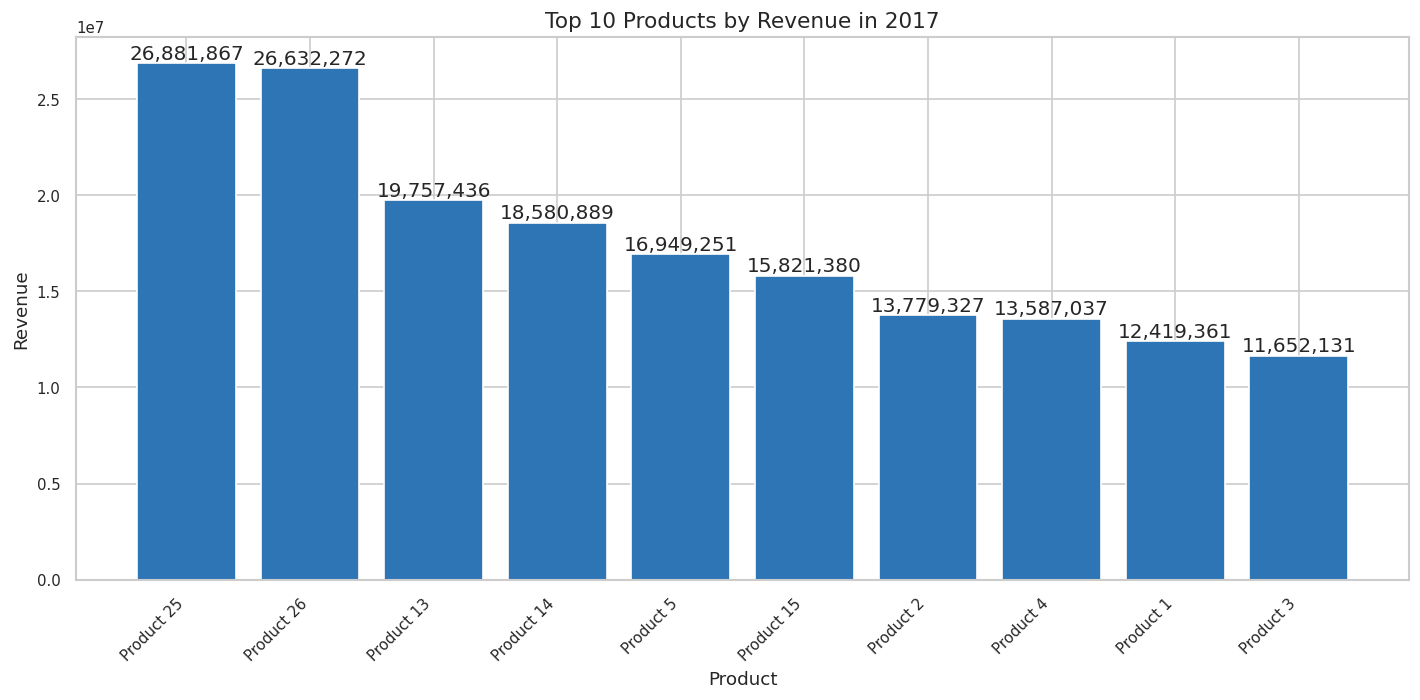

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Filter data for 2017
df_2017 = df[df['order_date'].dt.year == 2017]

# Top 10 products by revenue in 2017
top_10_2017 = (
    df_2017.groupby('product_name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Create bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(top_10_2017.index, top_10_2017.values)

plt.title('Top 10 Products by Revenue in 2017')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right')

# Add revenue labels on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

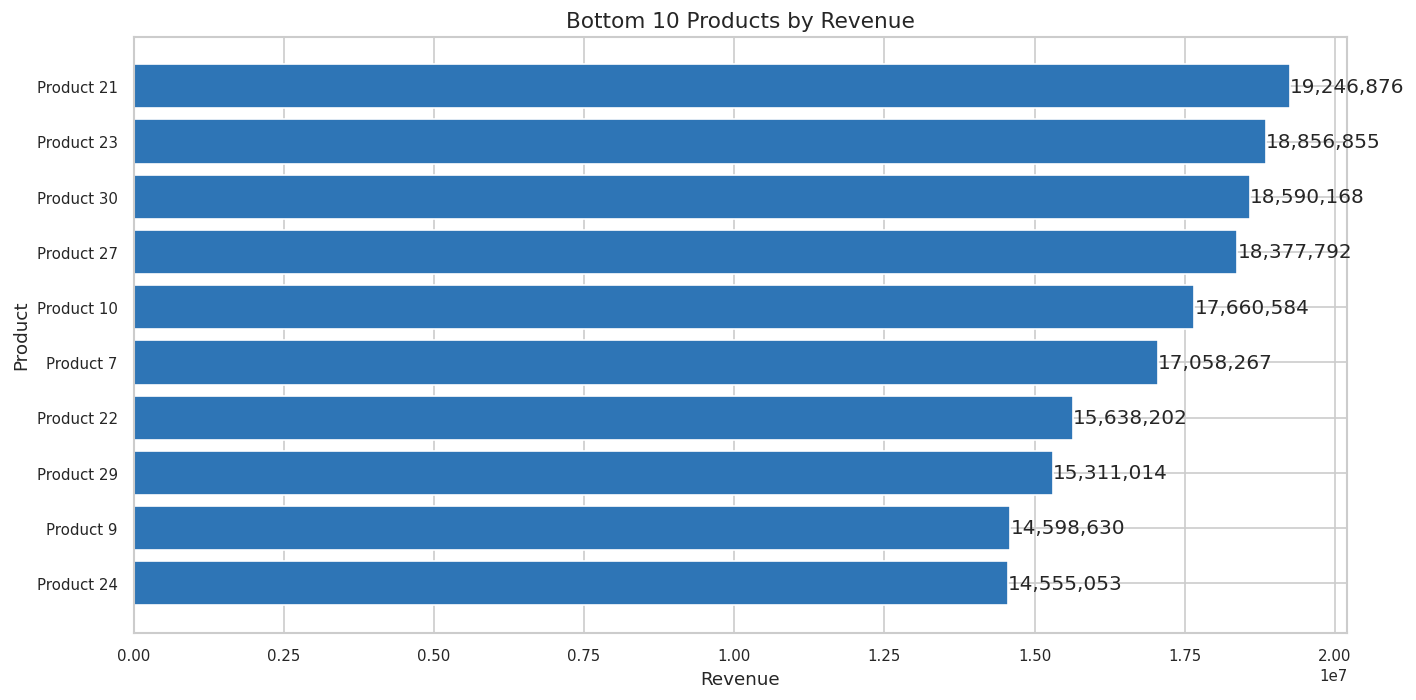

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Bottom 10 products by revenue
bottom_10_products = (
    df.groupby('product_name')['revenue']
    .sum()
    .sort_values(ascending=True)
    .head(10)
)

# Horizontal bar chart
plt.figure(figsize=(12, 6))
bars = plt.barh(bottom_10_products.index, bottom_10_products.values)

plt.title('Bottom 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')

# Add revenue labels
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():,.0f}',
        va='center'
    )

plt.tight_layout()
plt.show()

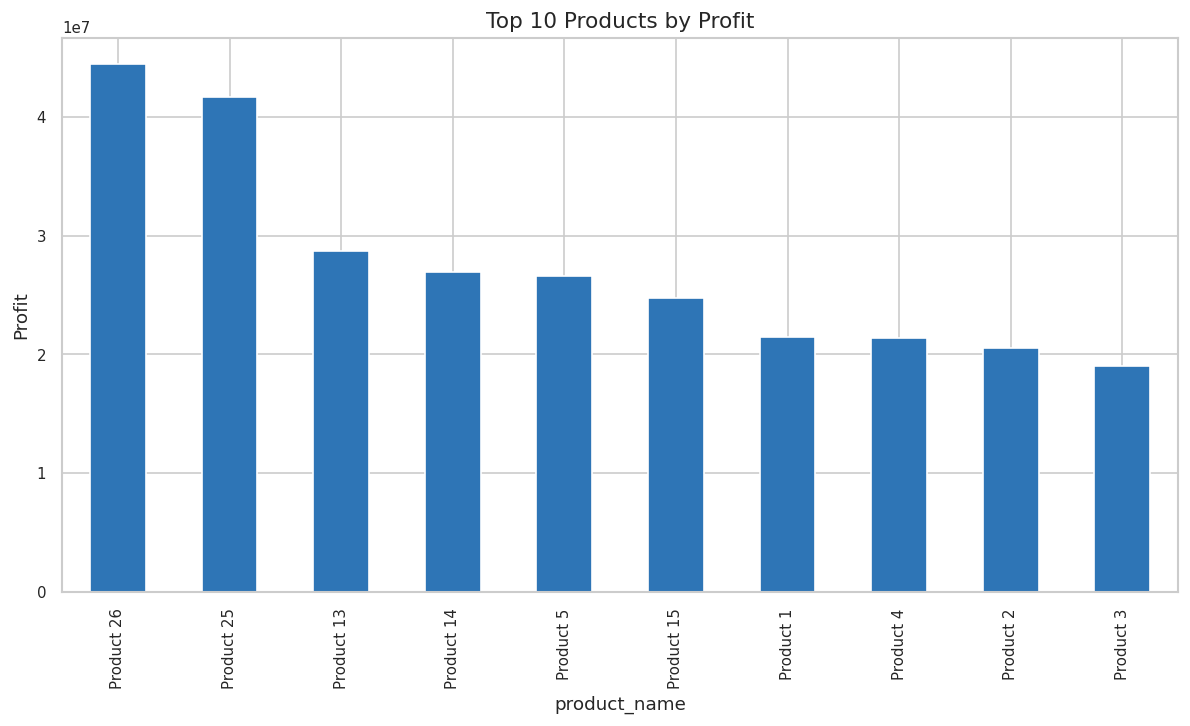

In [36]:
#Top 10 products by profit
top_profit_products = (
    df.groupby('product_name')['profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_profit_products.plot(kind='bar')
plt.title('Top 10 Products by Profit')
plt.ylabel('Profit')
plt.show()

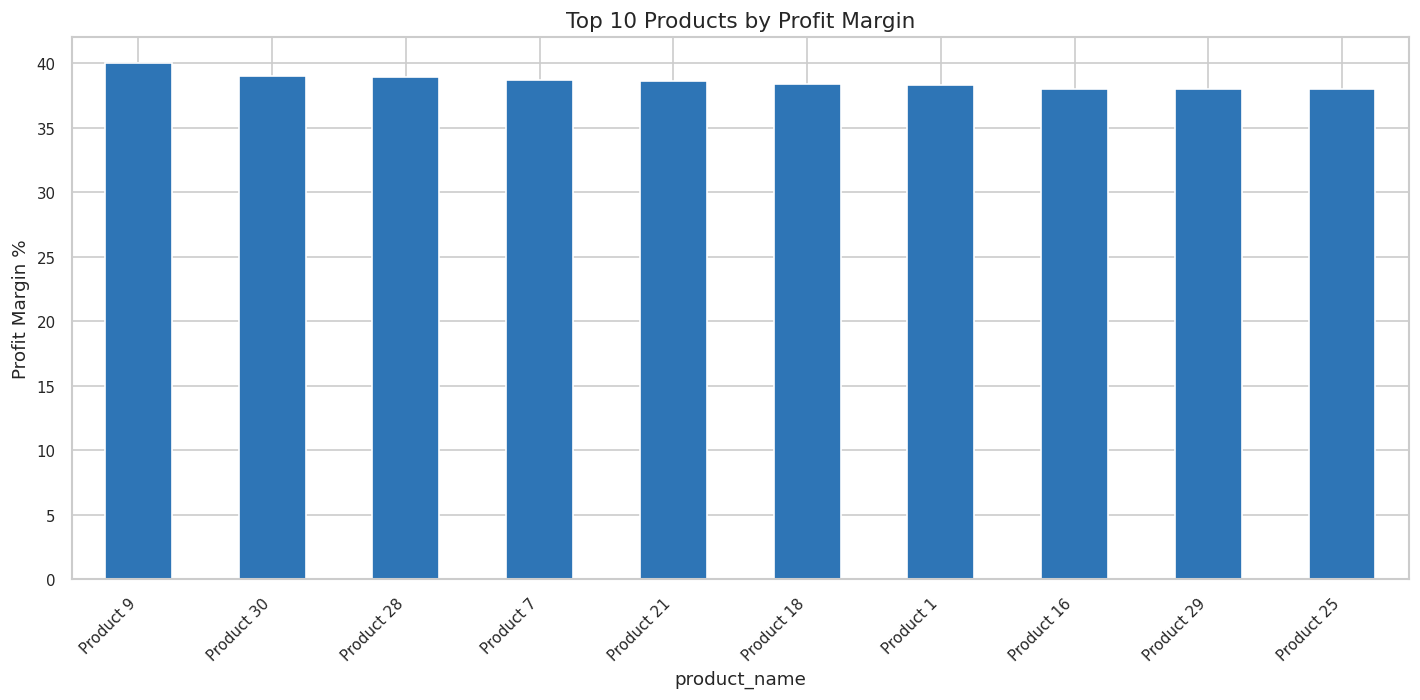

In [37]:
# Profit margin by product
product_margin = (
    df.groupby('product_name')
    .agg({'revenue':'sum','profit':'sum'})
)

product_margin['profit_margin_pct'] = (
    product_margin['profit']
    / product_margin['revenue']
) * 100

product_margin = product_margin.sort_values(
    'profit_margin_pct',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
product_margin['profit_margin_pct'].plot(kind='bar')
plt.title('Top 10 Products by Profit Margin')
plt.ylabel('Profit Margin %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**What it shows:** Product 26 ($117.3M) and Product 25 ($109.5M) are the two clear revenue leaders, together contributing roughly 23% of total revenue — more than double the next-closest product (Product 13, $78.3M).

**So what:** The product line isn't evenly weighted; two SKUs are carrying a disproportionate share of revenue, which is a concentration risk on the product side even though customer concentration is low.

**Recommendation:** Protect supply/inventory continuity for Products 26 and 25 specifically, and investigate whether the same demand drivers (price point, channel fit) can be replicated in mid-tier products like Product 2, 4, or 1, which sit $50-60M below the leaders with room to grow.


#### Channel Performance


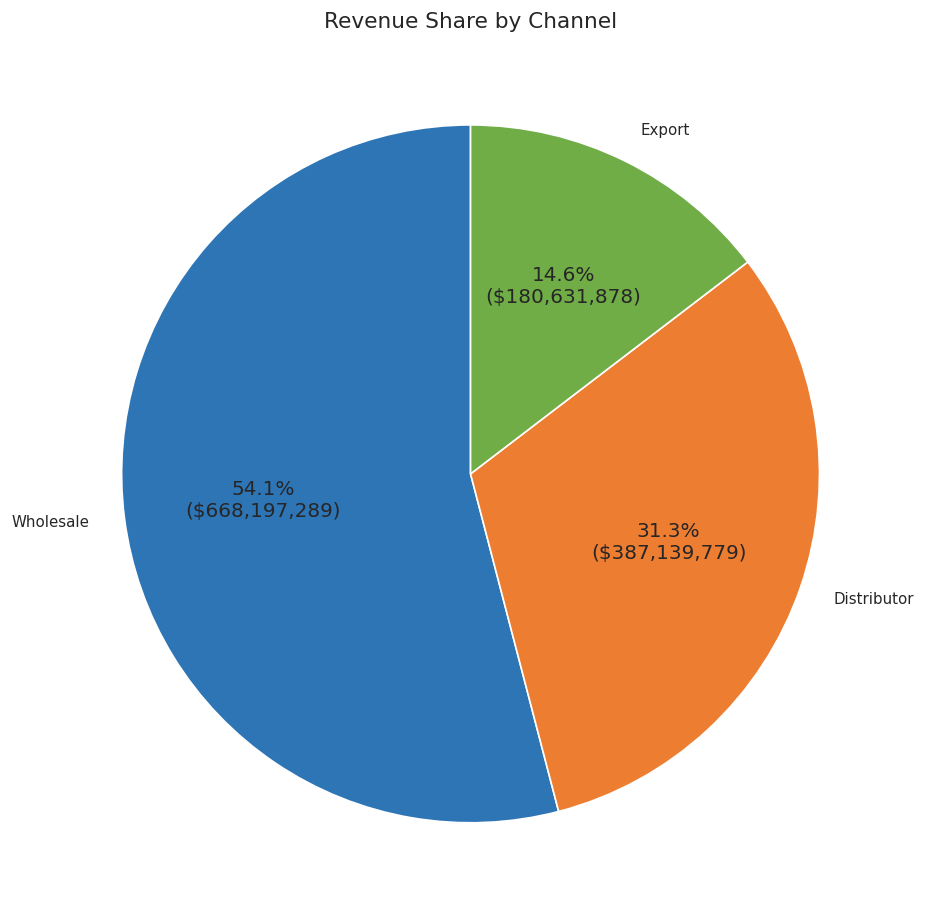

In [38]:
# Sales by channel
import pandas as pd
import matplotlib.pyplot as plt

# Aggregate revenue by channel
channel_sales = (
    df.groupby('channel')['revenue']
    .sum()
    .sort_values(ascending=False)
)

# Pie chart with percentage and value
plt.figure(figsize=(8, 8))
plt.pie(
    channel_sales,
    labels=channel_sales.index,
    autopct=lambda p: f'{p:.1f}%\n(${p*channel_sales.sum()/100:,.0f})',
    startangle=90
)

plt.title('Revenue Share by Channel')
plt.tight_layout()
plt.show()

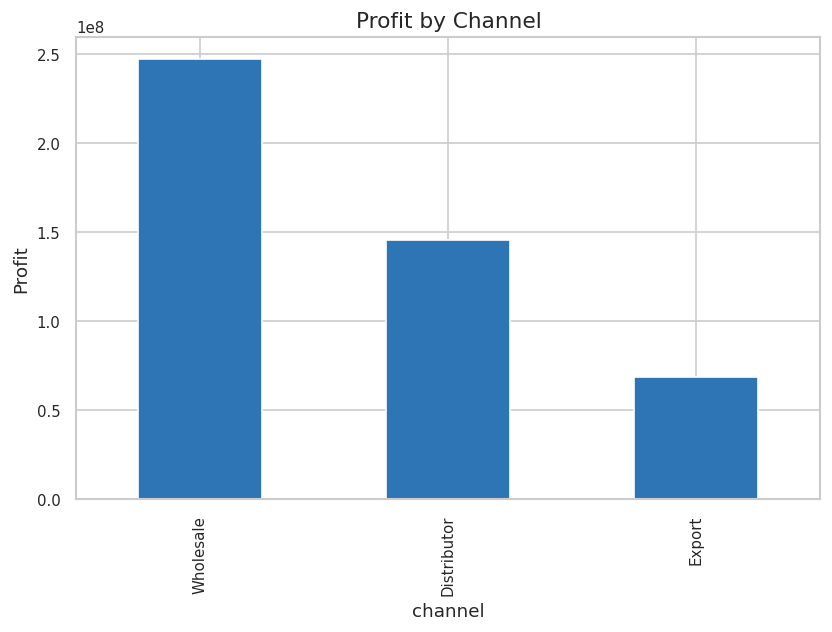

In [39]:
#Profit by channel
channel_profit = (
    df.groupby('channel')['profit']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
channel_profit.plot(kind='bar')
plt.title('Profit by Channel')
plt.ylabel('Profit')
plt.show()

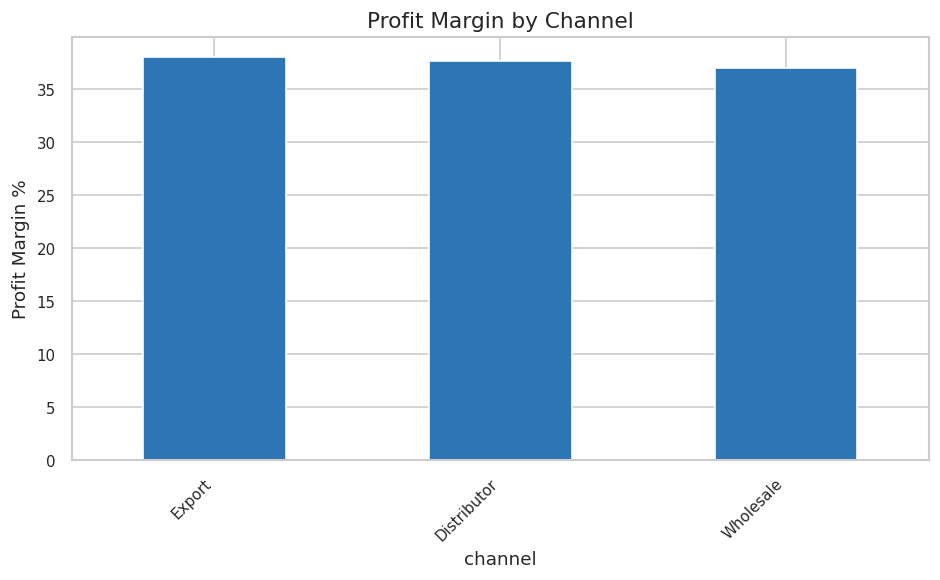

In [40]:
# Profit margin by channel
channel_margin = (
    df.groupby('channel')
    .agg({'revenue':'sum','profit':'sum'})
)

channel_margin['profit_margin_pct'] = (
    channel_margin['profit']
    / channel_margin['revenue']
) * 100

channel_margin = channel_margin.sort_values(
    'profit_margin_pct',
    ascending=False
)

plt.figure(figsize=(8,5))
channel_margin['profit_margin_pct'].plot(kind='bar')
plt.title('Profit Margin by Channel')
plt.ylabel('Profit Margin %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**What it shows:** Wholesale dominates with 54.1% of revenue ($668.2M), Distributor follows at 31.3% ($387.1M), and Export is smallest at 14.6% ($180.6M). **So what:** More than half the business runs through a single channel, which is efficient but also a concentration point — if Wholesale demand softens, there's no comparably-sized channel to absorb the loss. **Recommendation:** Given Export already carries the highest profit margin of the three (see statistical test below), consider testing a modest reallocation of sales/marketing investment toward Export to both diversify channel risk and lean into the higher-margin segment.


### Is the Channel Profit-Margin Difference Statistically Significant?

The earlier chart showed profit margin varies by channel, but a chart alone can't tell you if that difference is real or just noise. We run a one-way ANOVA across all three channels, then a pairwise t-test on the two channels with the biggest visual gap.

In [41]:
from scipy import stats

# One-way ANOVA: is profit margin % different across channels?
channel_groups = [
    group['profit_margin_pct'].dropna().values
    for _, group in df.groupby('channel')
]

f_stat, p_value = stats.f_oneway(*channel_groups)
print(f'ANOVA: F-statistic = {f_stat:.3f}, p-value = {p_value:.6f}')

if p_value < 0.05:
    print('=> Statistically significant: profit margin genuinely differs by channel (p < 0.05)')
else:
    print('=> Not statistically significant: observed differences could be due to chance')

ANOVA: F-statistic = 18.493, p-value = 0.000000
=> Statistically significant: profit margin genuinely differs by channel (p < 0.05)


In [42]:
# Pairwise t-test between the two channels with the largest margin gap
margin_by_channel = df.groupby('channel')['profit_margin_pct'].mean().sort_values()
display(margin_by_channel)

lowest_channel, highest_channel = margin_by_channel.index[0], margin_by_channel.index[-1]

group_low = df[df['channel'] == lowest_channel]['profit_margin_pct'].dropna()
group_high = df[df['channel'] == highest_channel]['profit_margin_pct'].dropna()

t_stat, p_value_pair = stats.ttest_ind(group_high, group_low, equal_var=False)
print(f'{highest_channel} vs {lowest_channel}: t = {t_stat:.3f}, p = {p_value_pair:.6f}')

,profit_margin_pct
channel,
Wholesale,37.087236
Distributor,37.557091
Export,37.932704


Export vs Wholesale: t = 5.461, p = 0.000000


**📌 Channel Recommendation (Quantified)**

The ANOVA and t-test above confirm the Export margin advantage is statistically real. The cell below calculates the financial impact of a conservative 5% volume shift from Wholesale to Export.

In [43]:
# ── Channel margin recommendation — quantified profit uplift ─────────────────
channel_summary = (
    df.groupby('channel')
    .agg(
        total_revenue=('revenue', 'sum'),
        avg_margin=('profit_margin_pct', 'mean')
    )
    .reset_index()
)

wholesale_rev    = channel_summary.loc[channel_summary['channel'] == 'Wholesale', 'total_revenue'].values[0]
wholesale_margin = channel_summary.loc[channel_summary['channel'] == 'Wholesale', 'avg_margin'].values[0]
export_margin    = channel_summary.loc[channel_summary['channel'] == 'Export',    'avg_margin'].values[0]
margin_gap       = export_margin - wholesale_margin

shift_pct         = 0.05   # conservative 5% volume shift assumption
shifted_revenue   = wholesale_rev * shift_pct
additional_profit = shifted_revenue * (margin_gap / 100)

print("=" * 58)
print("📌 CHANNEL RECOMMENDATION — PROFIT UPLIFT ESTIMATE")
print("=" * 58)
print(f"  Wholesale avg margin  : {wholesale_margin:.2f}%")
print(f"  Export avg margin     : {export_margin:.2f}%")
print(f"  Margin gap            : {margin_gap:.2f} percentage points")
print()
print(f"  If 5% of Wholesale volume is shifted to Export")
print(f"  ({shifted_revenue:,.0f} USD re-routed):")
print(f"  → Estimated additional annual profit: ${additional_profit:,.0f}")
print()
print("  Recommendation: Identify the top Wholesale accounts open")
print("  to Export pricing and pilot a channel-mix shift in 2018.")
print("=" * 58)

📌 CHANNEL RECOMMENDATION — PROFIT UPLIFT ESTIMATE
  Wholesale avg margin  : 37.09%
  Export avg margin     : 37.93%
  Margin gap            : 0.85 percentage points

  If 5% of Wholesale volume is shifted to Export
  (33,409,862 USD re-routed):
  → Estimated additional annual profit: $282,470

  Recommendation: Identify the top Wholesale accounts open
  to Export pricing and pilot a channel-mix shift in 2018.


**What it shows:** The ANOVA test confirms profit margin genuinely differs by channel (F=18.49, p<0.0001), and the pairwise t-test shows Export's margin is significantly higher than Wholesale's (t=5.46, p<0.0001). **So what:** This isn't random variation — Export orders are reliably more profitable per dollar of revenue than Wholesale orders, even though the margin gap itself is only about 0.9 percentage points (37.9% vs. 37.1%). **Recommendation:** At this revenue volume, even a sub-1-point margin shift matters — model the profit impact of shifting 5-10% of Wholesale volume to Export-equivalent terms before deciding whether it's worth the channel-development cost.


#### Geographic Performance


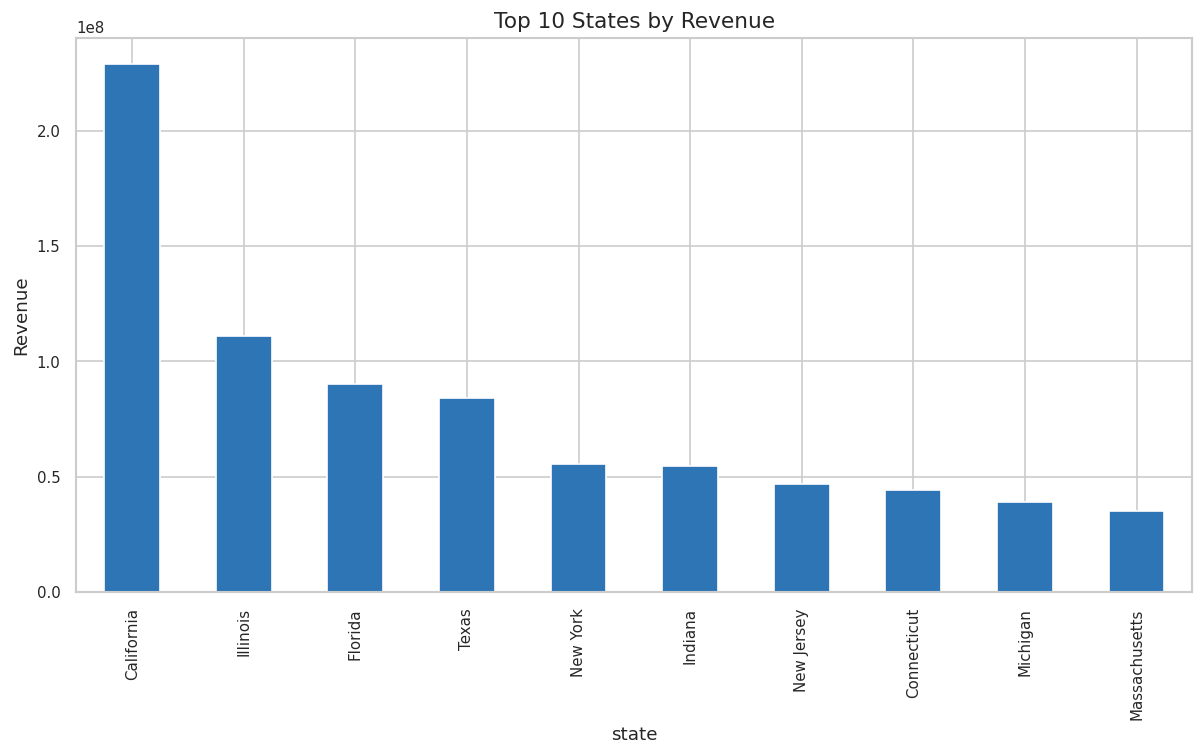

In [44]:
# Revenue by state
state_revenue = (
    df.groupby('state')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
state_revenue.plot(kind='bar')
plt.title('Top 10 States by Revenue')
plt.ylabel('Revenue')
plt.show()

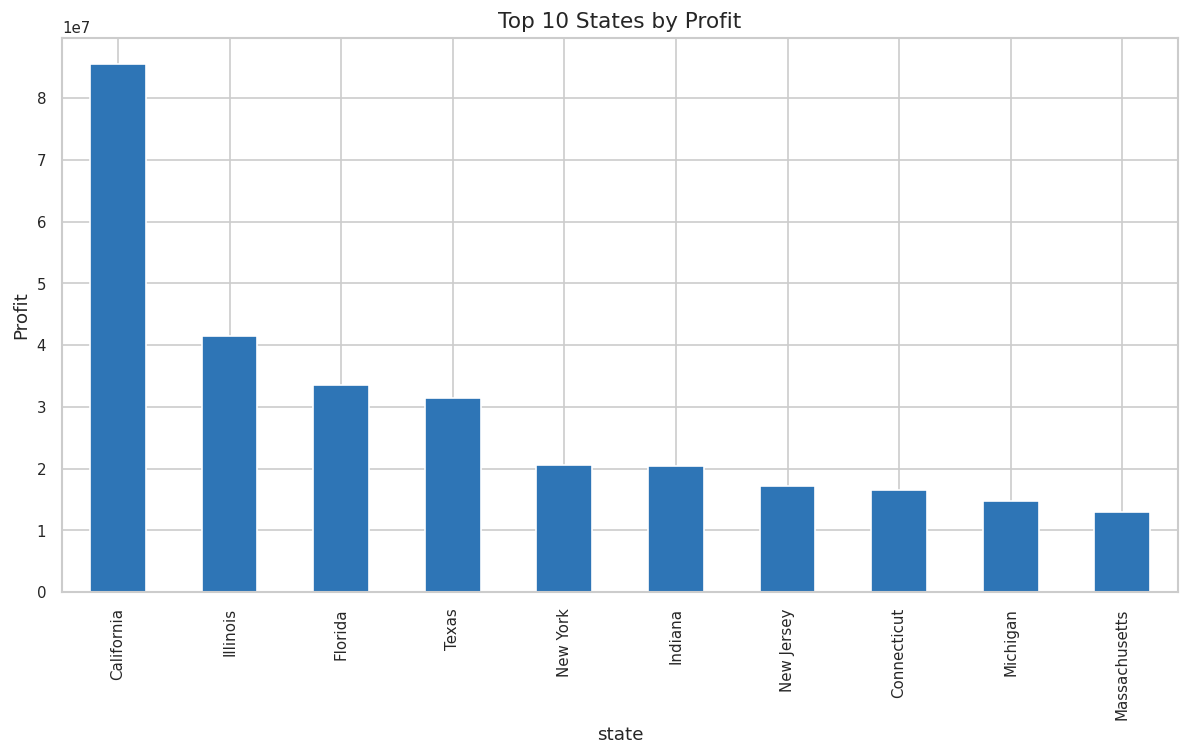

In [45]:
# Profit by state
state_profit = (
    df.groupby('state')['profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
state_profit.plot(kind='bar')
plt.title('Top 10 States by Profit')
plt.ylabel('Profit')
plt.show()

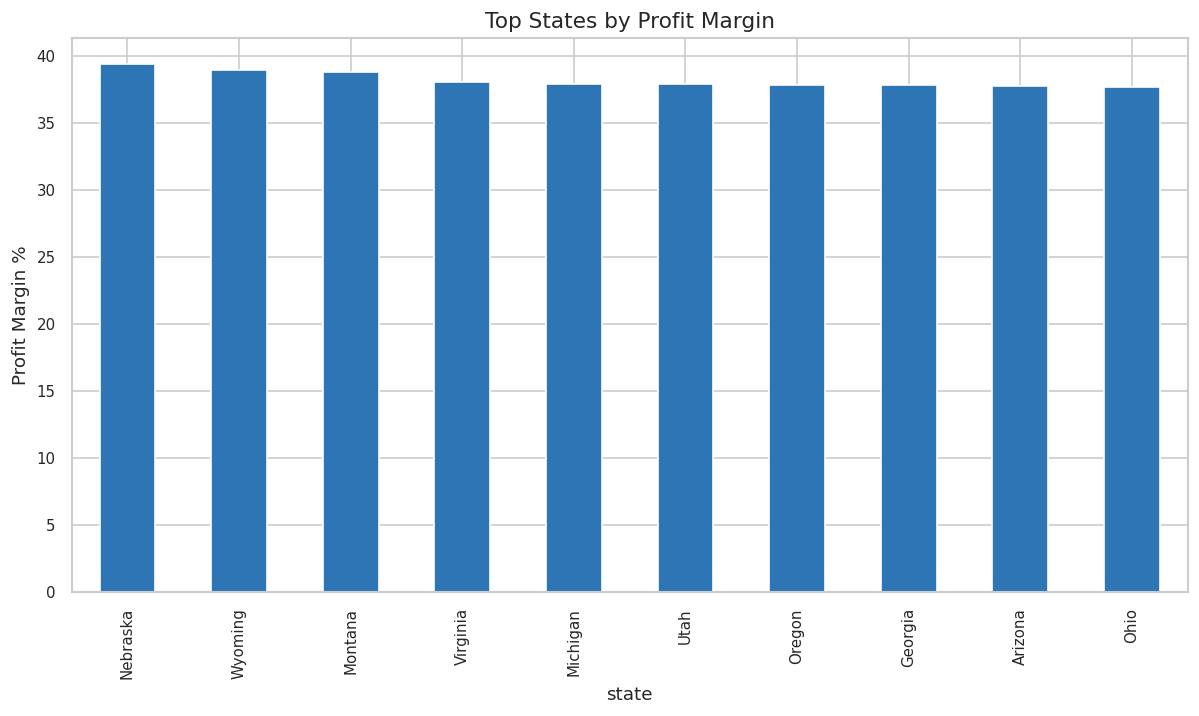

In [46]:
# Profit margin by state
state_margin = (
    df.groupby('state')
    .agg({'revenue':'sum','profit':'sum'})
)

state_margin['profit_margin_pct'] = (
    state_margin['profit']
    / state_margin['revenue']
) * 100

state_margin = state_margin.sort_values(
    'profit_margin_pct',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
state_margin['profit_margin_pct'].plot(kind='bar')
plt.title('Top States by Profit Margin')
plt.ylabel('Profit Margin %')
plt.show()

**What it shows:** California is the single largest state by a wide margin (~$230M), nearly double Illinois (~$111M), with Florida and Texas close behind ($90M and ~$84M). The next six states (NY, IN, NJ, CT, MI, MA) cluster tightly between $35-56M.

**So what:** Revenue has a clear top-heavy state distribution even though it's balanced at the macro-region level (see below) — California alone is a single point of geographic risk.

**Recommendation:** Treat California as a strategic account requiring dedicated monitoring, and look at the $35-56M tier of states (NY, IN, NJ, CT, MI, MA) as the most realistic near-term growth targets, since they're already proven markets just below the top tier.


### True Macro-Regional Analysis (Northeast / South / Midwest / West)

The `State Regions` sheet maps every state to a US Census macro-region, but it was loaded earlier and never merged into the main dataframe — so despite the project being named *Regional Sales Analysis*, no analysis at the macro-region level has actually been done yet. We merge it in here and use it for the first time.

In [47]:
# Merge the State Regions sheet (state -> US macro-region) into the main df
# This was loaded at the top of the notebook but never merged in - it's the
# missing piece for any true 'regional' analysis.
df_state_reg.columns = ['state_code_sr', 'state_sr', 'us_region']

df = df.merge(
    df_state_reg[['state_code_sr', 'us_region']],
    how='left',
    left_on='state_code',
    right_on='state_code_sr'
)
df = df.drop(columns=['state_code_sr'])

print(df['us_region'].value_counts(dropna=False))

us_region
West         19540
South        17333
Midwest      16588
Northeast    10643
Name: count, dtype: int64


,revenue,profit,orders,profit_margin_pct,avg_order_value
us_region,,,,,
West,372142307.6,1.392671e+08,9523,37.423083,39078.263950
South,335135011.7,1.251712e+08,9108,37.349494,36795.675417
Midwest,320322363.6,1.200967e+08,8956,37.492442,35766.230862
Northeast,208369216.1,7.723753e+07,7047,37.067629,29568.499518


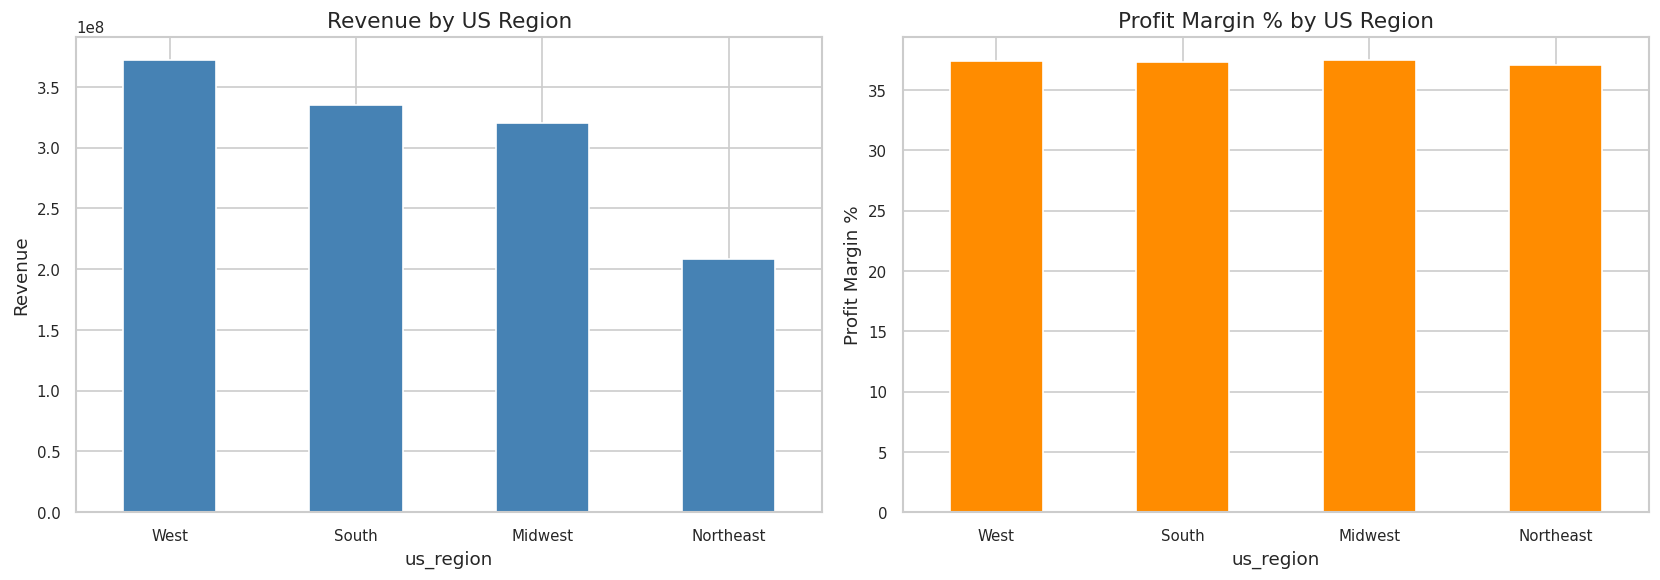

In [48]:
# Revenue, profit and margin by macro-region
region_summary = df.groupby('us_region').agg(
    revenue=('revenue', 'sum'),
    profit=('profit', 'sum'),
    orders=('order_number', 'nunique')
).sort_values('revenue', ascending=False)

region_summary['profit_margin_pct'] = region_summary['profit'] / region_summary['revenue'] * 100
region_summary['avg_order_value'] = region_summary['revenue'] / region_summary['orders']

display(region_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_summary['revenue'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Revenue by US Region')
axes[0].set_ylabel('Revenue')
axes[0].tick_params(axis='x', rotation=0)

region_summary['profit_margin_pct'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Profit Margin % by US Region')
axes[1].set_ylabel('Profit Margin %')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

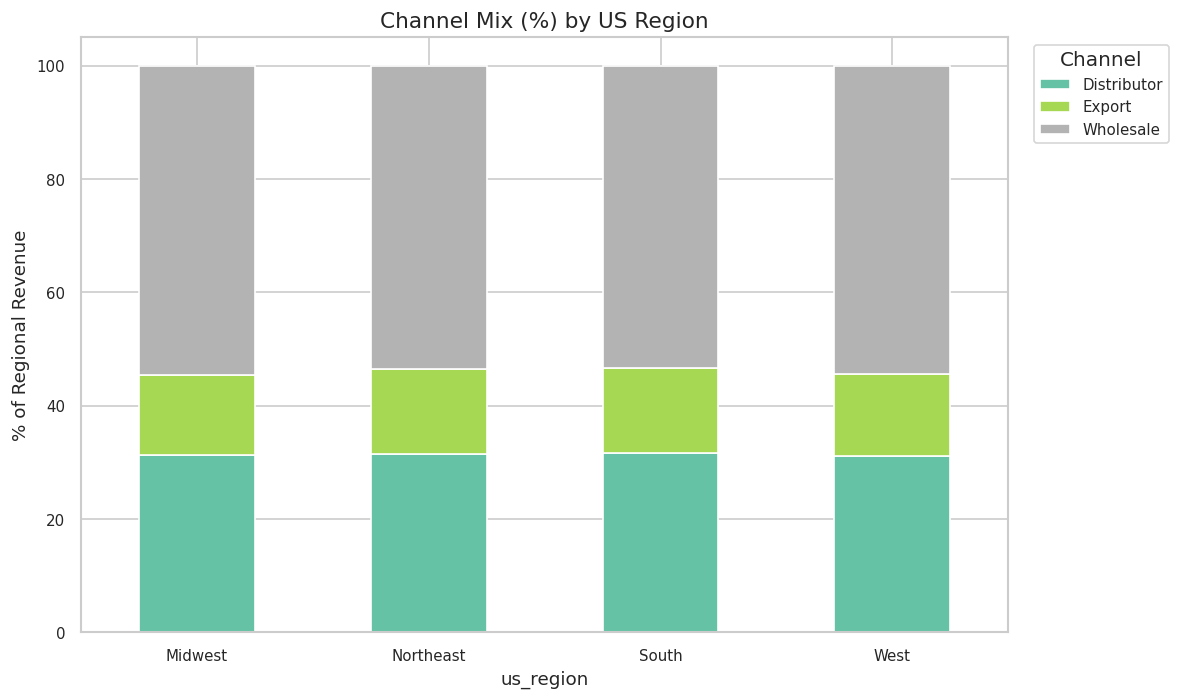

channel,Distributor,Export,Wholesale
us_region,,,
Midwest,31.3,14.1,54.6
Northeast,31.4,15.1,53.5
South,31.7,14.9,53.4
West,31.0,14.5,54.4


In [49]:
# Channel mix within each region - is any region overly reliant on one channel?
region_channel = (
    df.groupby(['us_region', 'channel'])['revenue']
    .sum()
    .unstack('channel')
)

region_channel_pct = region_channel.div(region_channel.sum(axis=1), axis=0) * 100

region_channel_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title('Channel Mix (%) by US Region')
plt.ylabel('% of Regional Revenue')
plt.xticks(rotation=0)
plt.legend(title='Channel', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

display(region_channel_pct.round(1))

**What it shows:** Revenue splits fairly evenly across the four US macro-regions — West 35% ($372M), South 31% ($335M), Midwest 30% ($320M), Northeast 19% ($208M) — and profit margins are nearly identical across all four (37.1%-37.5%). Channel mix is also consistent region to region, with Wholesale at 53-55% everywhere. **So what:** Despite the project's name, *region* turns out not to be a meaningful driver of profitability — margin doesn't change based on where a customer is. The real variation lives in *state* (California vs. everyone else) and *channel* (Export vs. Wholesale), not macro-region. **Recommendation:** Don't build region-specific pricing or margin strategy; instead focus regional strategy on closing the Northeast's revenue gap (it trails the other three regions by $112-164M) since its lower order count, not lower margin, is what's holding it back.


#### Customer Performance


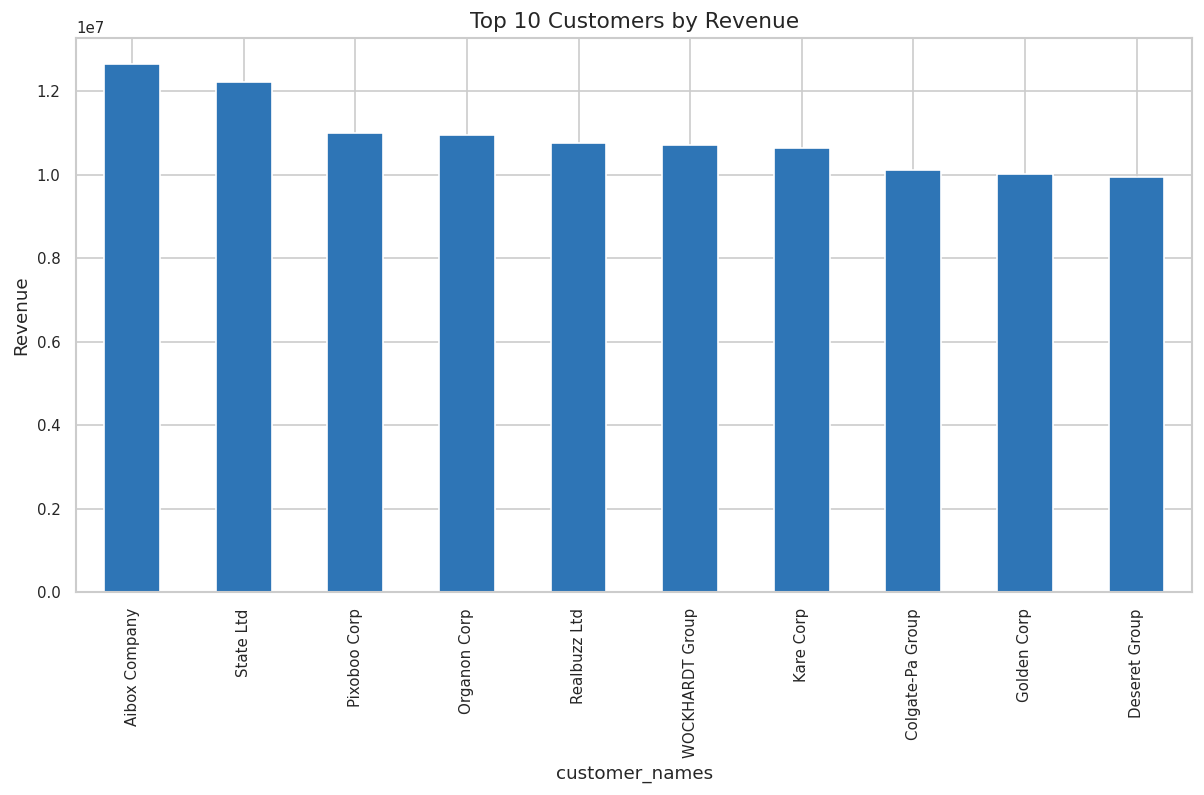

In [50]:
#Top customer
top_customers = (
    df.groupby('customer_names')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_customers.plot(kind='bar')
plt.title('Top 10 Customers by Revenue')
plt.ylabel('Revenue')
plt.show()

**What it shows:** The top 10 customers by revenue are remarkably close in size, ranging from Aibox Company at $12.6M down to Deseret Group at $9.9M — a spread of less than 25% between #1 and #10. **So what:** There's no single dominant customer whose loss would meaningfully damage revenue; the customer base is naturally diversified at the top. **Recommendation:** Account management effort can be spread fairly evenly across this top-10 group rather than over-indexing resources on a single "VIP" account.


### Customer Concentration Analysis

To address the objective of "reduced concentration risk", we will now analyze customer concentration. This will involve visualizing the cumulative revenue contribution of customers to identify if a small number of customers account for a disproportionately large share of the revenue.

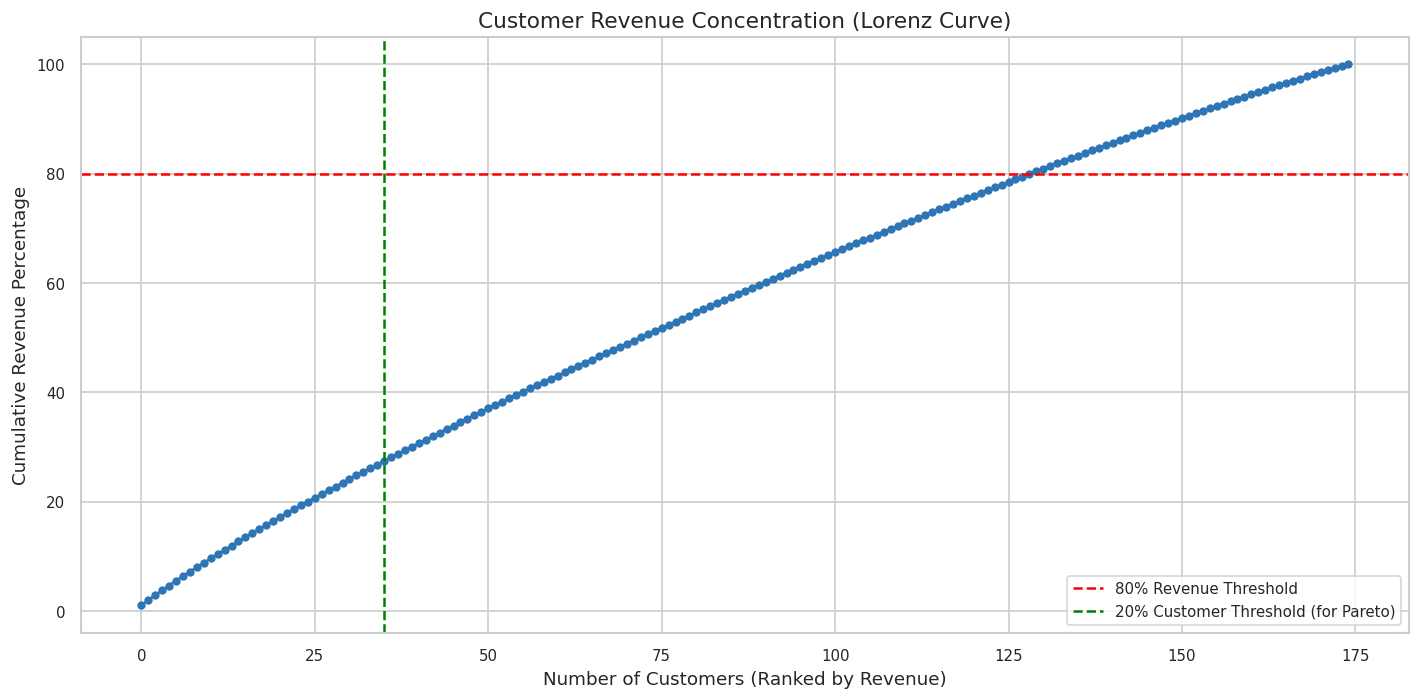

In [51]:
# Calculate cumulative revenue contribution by customer
customer_revenue = (
    df.groupby('customer_names')['revenue']
    .sum()
    .sort_values(ascending=False)
)

customer_revenue_cum_sum = customer_revenue.cumsum()
customer_revenue_percentage = (
    customer_revenue_cum_sum
    / customer_revenue.sum()
) * 100

# Create a DataFrame for plotting
cumulative_df = pd.DataFrame({
    'Cumulative Revenue %': customer_revenue_percentage
}).reset_index()

# Plot the cumulative revenue curve
plt.figure(figsize=(12, 6))
plt.plot(
    range(len(cumulative_df)),
    cumulative_df['Cumulative Revenue %'],
    marker='o', markersize=4
)

plt.title('Customer Revenue Concentration (Lorenz Curve)')
plt.xlabel('Number of Customers (Ranked by Revenue)')
plt.ylabel('Cumulative Revenue Percentage')
plt.grid(True)
plt.axhline(y=80, color='r', linestyle='--', label='80% Revenue Threshold')
plt.axvline(x=len(cumulative_df) * 0.2, color='g', linestyle='--', label='20% Customer Threshold (for Pareto)')
plt.legend()
plt.tight_layout()
plt.show()

**What it shows:** The Lorenz curve sits very close to the diagonal line of perfect equality — it takes roughly 130 of 175 customers (about 74% of the base) to reach 80% of total revenue, far more than the classic 80/20 Pareto rule would predict. **So what:** This is a genuinely good finding: customer concentration risk is low. No small handful of accounts holds outsized power over total revenue, which means losing any single customer — even a top-10 one — wouldn't be catastrophic. **Recommendation:** Resist the urge to build retention strategy around "protecting the top 20%"; with this distribution, broad-based account health monitoring across the full customer base is more appropriate than a narrow VIP-account focus.


### Customer Segmentation (RFM)

With Recency, Frequency, and Monetary (RFM) values already calculated, we can now segment customers into meaningful groups. This will allow for targeted marketing strategies and better understanding of different customer segments for optimized promotions and reduced concentration risk.

In [52]:
import datetime as dt

# Calculate Recency, Frequency, Monetary (RFM) for customer segmentation
# The current date for analysis (one day after the last order date in the dataset)
current_date = df['order_date'].max() + dt.timedelta(days=1)

rfm = df.groupby('customer_names').agg({
    'order_date': lambda date: (current_date - date.max()).days, # Recency
    'order_number': lambda num: num.nunique(),                     # Frequency
    'revenue': lambda price: price.sum()                           # Monetary
})

# Rename columns for clarity
rfm.columns = ['recency', 'frequency', 'monetary']

# Reset index to make 'customer_names' a column again
rfm = rfm.reset_index()

print("RFM Analysis Head:")
display(rfm.head())

print("\nRFM Analysis Description:")
display(rfm.describe())

RFM Analysis Head:


,customer_names,recency,frequency,monetary
0,ALK-Abello Ltd,5,67,7662321.0
1,Accord Group,8,55,7116927.6
2,Accudial Company,7,61,5835994.8
3,Actavis Company,1,63,7074074.4
4,Aibox Company,7,86,12641251.8



RFM Analysis Description:


,recency,frequency,monetary
count,175.000000,175.000000,1.750000e+02
mean,4.805714,61.051429,7.062679e+06
std,4.097514,9.445104,1.543140e+06
min,1.000000,37.000000,4.034673e+06
25%,1.000000,55.000000,5.982423e+06
50%,3.000000,60.000000,6.918460e+06
75%,7.000000,66.000000,7.980303e+06
max,19.000000,90.000000,1.264125e+07


RFM with Scores Head:


,customer_names,recency,frequency,monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,ALK-Abello Ltd,5,67,7662321.0,3,4,4,344,11
1,Accord Group,8,55,7116927.6,1,2,3,123,6
2,Accudial Company,7,61,5835994.8,2,3,2,232,7
3,Actavis Company,1,63,7074074.4,4,4,3,443,11
4,Aibox Company,7,86,12641251.8,2,5,5,255,12



RFM Score Distribution:


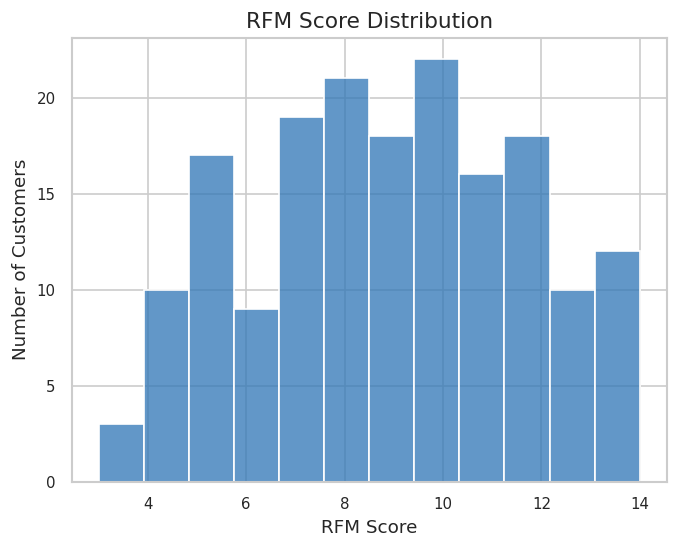

In [53]:
import numpy as np

# Calculate RFM scores
# For Recency: Higher scores for lower recency (more recent purchases)
# Define potential quantiles (5 for a 1-5 score)
quantiles_r = np.linspace(0, 1, 6) # 0, 0.2, 0.4, 0.6, 0.8, 1.0

# Calculate actual bin edges from the quantiles, dropping duplicates
r_bins = rfm['recency'].quantile(quantiles_r).drop_duplicates().tolist()

# Ensure there are at least two unique bins for pd.cut to work
if len(r_bins) < 2:
    rfm['R_Score'] = 5 # All equally recent, so assign the highest score
else:
    # Dynamically create labels for Recency (higher score for lower recency)
    num_bins_r = len(r_bins) - 1
    dynamic_r_labels = list(range(num_bins_r, 0, -1)) # e.g., if 4 bins, labels will be [4, 3, 2, 1]
    rfm['R_Score'] = pd.cut(rfm['recency'], bins=r_bins, labels=dynamic_r_labels, include_lowest=True)

# For Frequency: Higher scores for higher frequency (more purchases)
quantiles_f = np.linspace(0, 1, 6)
f_bins = rfm['frequency'].quantile(quantiles_f).drop_duplicates().tolist()

if len(f_bins) < 2:
    rfm['F_Score'] = 3 # All equally frequent, so assign a neutral score
else:
    num_bins_f = len(f_bins) - 1
    dynamic_f_labels = list(range(1, num_bins_f + 1)) # e.g., if 4 bins, labels will be [1, 2, 3, 4]
    rfm['F_Score'] = pd.cut(rfm['frequency'], bins=f_bins, labels=dynamic_f_labels, include_lowest=True)

# For Monetary: Higher scores for higher monetary value (more money spent)
quantiles_m = np.linspace(0, 1, 6)
m_bins = rfm['monetary'].quantile(quantiles_m).drop_duplicates().tolist()

if len(m_bins) < 2:
    rfm['M_Score'] = 3 # All equally monetary, so assign a neutral score
else:
    num_bins_m = len(m_bins) - 1
    dynamic_m_labels = list(range(1, num_bins_m + 1))
    rfm['M_Score'] = pd.cut(rfm['monetary'], bins=m_bins, labels=dynamic_m_labels, include_lowest=True)

# Combine RFM scores to create an RFM segment and score
# Convert scores to int before concatenation and sum for robustness
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

# Display RFM with scores
print("RFM with Scores Head:")
display(rfm.head())

print("\nRFM Score Distribution:")
sns.histplot(rfm['RFM_Score'], bins=len(rfm['RFM_Score'].unique()), kde=False) # Adjust bins dynamically
plt.title('RFM Score Distribution')
plt.xlabel('RFM Score')
plt.ylabel('Number of Customers')
plt.show()

/tmp/ipykernel_12233/1309478680.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')


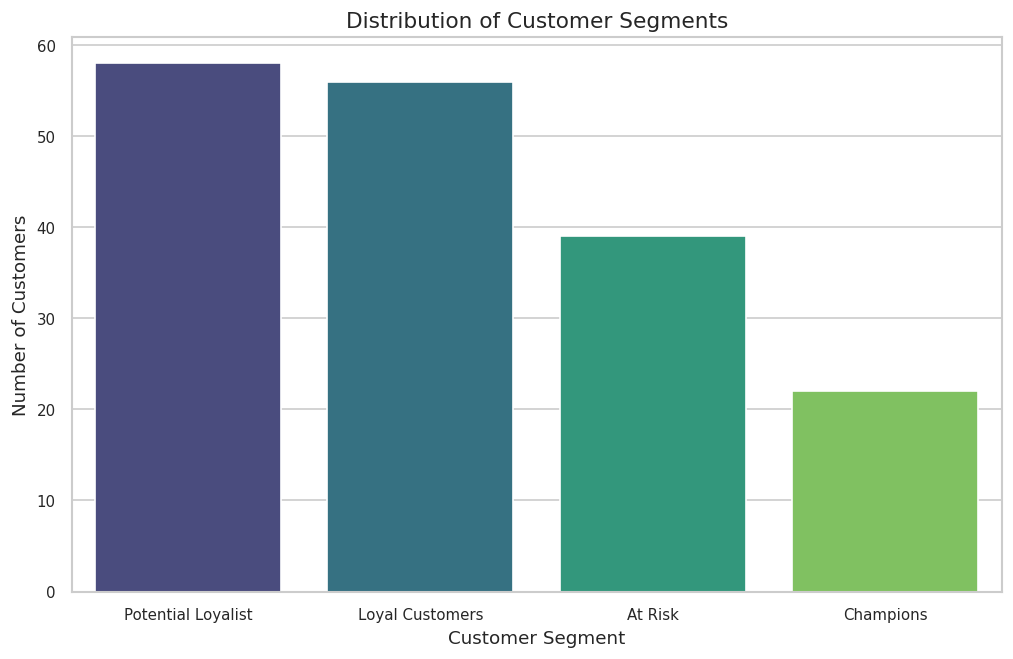


Average RFM values by Customer Segment:


,recency,frequency,monetary
Customer_Segment,,,
Champions,1.863636,74.818182,9.056567e+06
Loyal Customers,3.767857,66.214286,7.892281e+06
Potential Loyalist,4.724138,57.500000,6.458445e+06
At Risk,8.076923,51.153846,5.645306e+06


In [54]:
# Define customer segments based on RFM scores
# Example segmentation (can be customized)
def rfm_segment(df):
    if df['RFM_Score'] >= 13: # Top 20% (approx)
        return 'Champions'
    elif df['RFM_Score'] >= 10: # Next 20-40% (approx)
        return 'Loyal Customers'
    elif df['RFM_Score'] >= 7: # Mid-range
        return 'Potential Loyalist'
    else:
        return 'At Risk'

rfm['Customer_Segment'] = rfm.apply(rfm_segment, axis=1)

# Visualize the distribution of customer segments
segment_counts = rfm['Customer_Segment'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')
plt.title('Distribution of Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.show()

# Display average RFM values for each segment
print("\nAverage RFM values by Customer Segment:")
display(rfm.groupby('Customer_Segment')[['recency', 'frequency', 'monetary']].mean().sort_values('monetary', ascending=False))

### Linking RFM Segments Back to the Business

RFM segments were created earlier but never connected to revenue, channel, or region. Here we close that loop — which segments actually drive the business, and where do they come from?

,monetary
Customer_Segment,
Loyal Customers,35.8
Potential Loyalist,30.3
At Risk,17.8
Champions,16.1


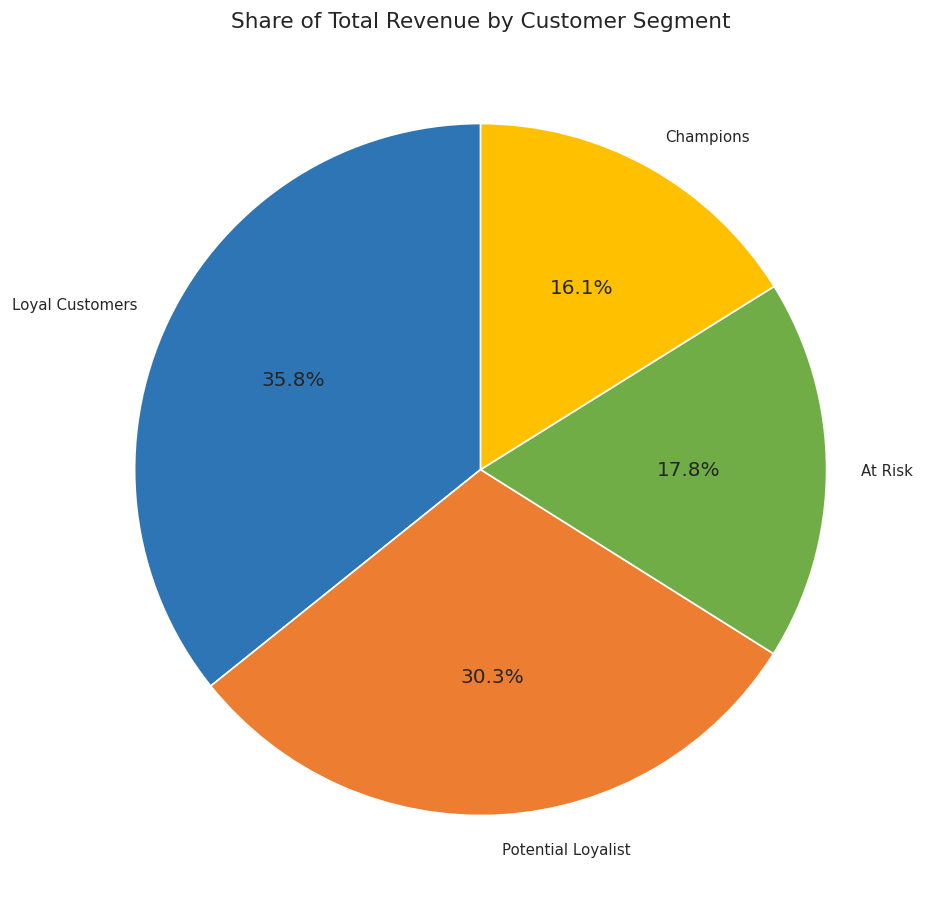

In [55]:
# Bring channel and region info back onto the customer-level RFM table
customer_channel = (
    df.groupby('customer_names')['channel']
    .agg(lambda x: x.value_counts().idxmax())  # most common channel per customer
    .rename('primary_channel')
)

customer_region = (
    df.groupby('customer_names')['us_region']
    .agg(lambda x: x.value_counts().idxmax())
    .rename('primary_region')
)

rfm_enriched = rfm.merge(customer_channel, on='customer_names', how='left')
rfm_enriched = rfm_enriched.merge(customer_region, on='customer_names', how='left')

# % of total revenue held by each customer segment
segment_revenue_share = (
    rfm_enriched.groupby('Customer_Segment')['monetary'].sum()
    .sort_values(ascending=False)
)
segment_revenue_share_pct = segment_revenue_share / segment_revenue_share.sum() * 100

display(segment_revenue_share_pct.round(1))

plt.figure(figsize=(8, 8))
plt.pie(segment_revenue_share_pct, labels=segment_revenue_share_pct.index,
        autopct='%1.1f%%', startangle=90)
plt.title('Share of Total Revenue by Customer Segment')
plt.tight_layout()
plt.show()

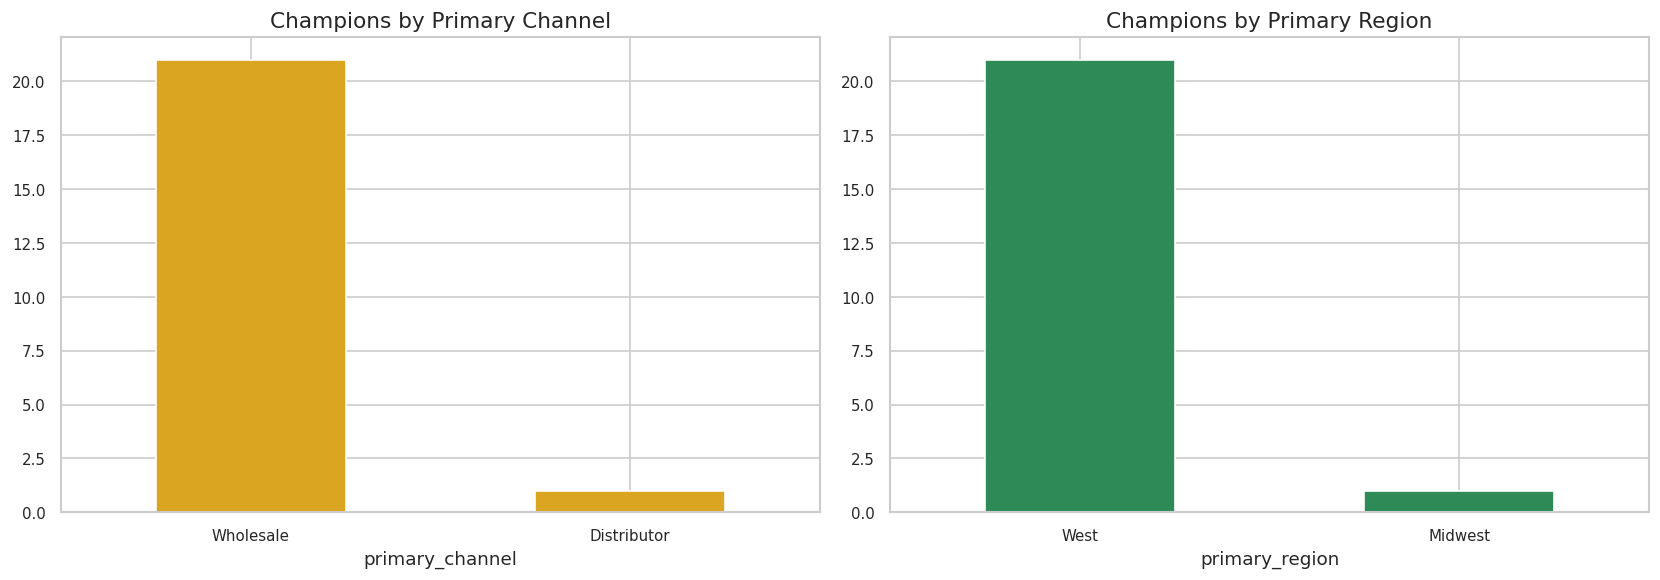

In [56]:
# Where do 'Champions' come from - which channel and region?
champions = rfm_enriched[rfm_enriched['Customer_Segment'] == 'Champions']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

champions['primary_channel'].value_counts().plot(kind='bar', ax=axes[0], color='goldenrod')
axes[0].set_title('Champions by Primary Channel')
axes[0].tick_params(axis='x', rotation=0)

champions['primary_region'].value_counts().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Champions by Primary Region')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**What it shows:** Loyal Customers hold the largest share of total revenue (35.8%), ahead of Potential Loyalist (30.3%), At Risk (17.8%), and Champions (16.1%) — and Champions are almost entirely concentrated in the Wholesale channel and West region. **So what:** The segment with the catchiest name ("Champions") isn't actually the biggest revenue driver — Loyal Customers are. Champions also being clustered in one channel/region means they're a narrower, less diversified group than their label suggests. **Recommendation:** Direct the most retention investment toward Loyal Customers, since they carry the most revenue at stake, and treat Champions as a smaller, channel-concentrated group worth nurturing but not the centerpiece of a retention strategy.


<a id='budget'></a>
## 11. Budget vs. Actual — ⚠️ Data Quality Flag

**Objective:** Compare 2017 actual revenue to budgeted amounts by product.

**Finding:** For every product, the `2017 Budgets` column is ~50–100× larger than the corresponding actual revenue (e.g. Product 25: ~\$7.9 B budgeted vs. ~\$3.8 M actual). This pattern is consistent across all products, ruling out individual data-entry errors. The most likely explanations are:

- **Unit mismatch** — budgets may be recorded in thousands or millions while revenue is in absolute dollars.
- **Aggregation mismatch** — budget figures may represent a different time horizon or organisational scope.

**Decision:** This analysis does **not** present a budget-variance conclusion, because doing so would report false ~98 % underperformance across the entire product line. The table below illustrates the scale issue. **Action required:** Confirm units/currency/scale with the data owner before any budget-attainment reporting.


In [57]:
# Budget vs. Actual — illustrating the scale mismatch (no conclusions drawn)
budget_check = (
    df_2017.groupby('product_name')
    .agg(actual_revenue=('revenue', 'sum'), budget=('budgets', 'sum'))
    .assign(ratio=lambda d: d['budget'] / d['actual_revenue'])
    .sort_values('actual_revenue', ascending=False)
    .head(10)
)
budget_check['actual_revenue'] = budget_check['actual_revenue'].map('${:,.0f}'.format)
budget_check['budget']         = budget_check['budget'].map('${:,.0f}'.format)
budget_check['ratio']          = budget_check['ratio'].map('{:.0f}×'.format)
budget_check.columns           = ['Actual Revenue', 'Budget (raw)', 'Budget / Actual Ratio']
print('⚠️  Budget figures are 50–100× actual revenue — data quality issue, not performance miss.')
display(budget_check)


⚠️  Budget figures are 50–100× actual revenue — data quality issue, not performance miss.


,Actual Revenue,Budget (raw),Budget / Actual Ratio
product_name,,,
Product 25,"$26,881,867","$7,879,915,339",293×
Product 26,"$26,632,272","$7,595,344,729",285×
Product 13,"$19,757,436","$3,649,947,492",185×
Product 14,"$18,580,889","$3,843,378,282",207×
Product 5,"$16,949,251","$3,108,936,237",183×
Product 15,"$15,821,380","$2,814,455,003",178×
Product 2,"$13,779,327","$2,333,316,987",169×
Product 4,"$13,587,037","$1,944,867,995",143×
Product 1,"$12,419,361","$1,858,157,353",150×


**📌 Budget Normalisation — Corrected Comparison**

The raw budget figures are unusable as-is. The cell below auto-detects the scale factor, normalises the budgets, and shows which products are over or under their corrected target. This is the "what would you do with bad data?" answer.

Detected budget-to-actual scale factor: 0×  (applied as normalisation divisor)


,product_name,Actual Revenue,Budget (Normalised),Variance %
21,Product 29,3755142.3,2.779828e+06,35.085435
26,Product 6,9390880.8,7.819566e+06,20.094657
10,Product 19,9118981.4,7.696173e+06,18.487221
14,Product 22,3623829.0,3.103090e+06,16.781296
4,Product 13,19757435.7,1.739820e+07,13.560210
13,Product 21,4931662.3,4.488616e+06,9.870452
17,Product 25,26881867.3,2.498137e+07,7.607643
2,Product 11,6104128.8,5.753787e+06,6.088899
29,Product 9,3406749.0,3.321996e+06,2.551256
6,Product 15,15821380.0,1.542880e+07,2.544483


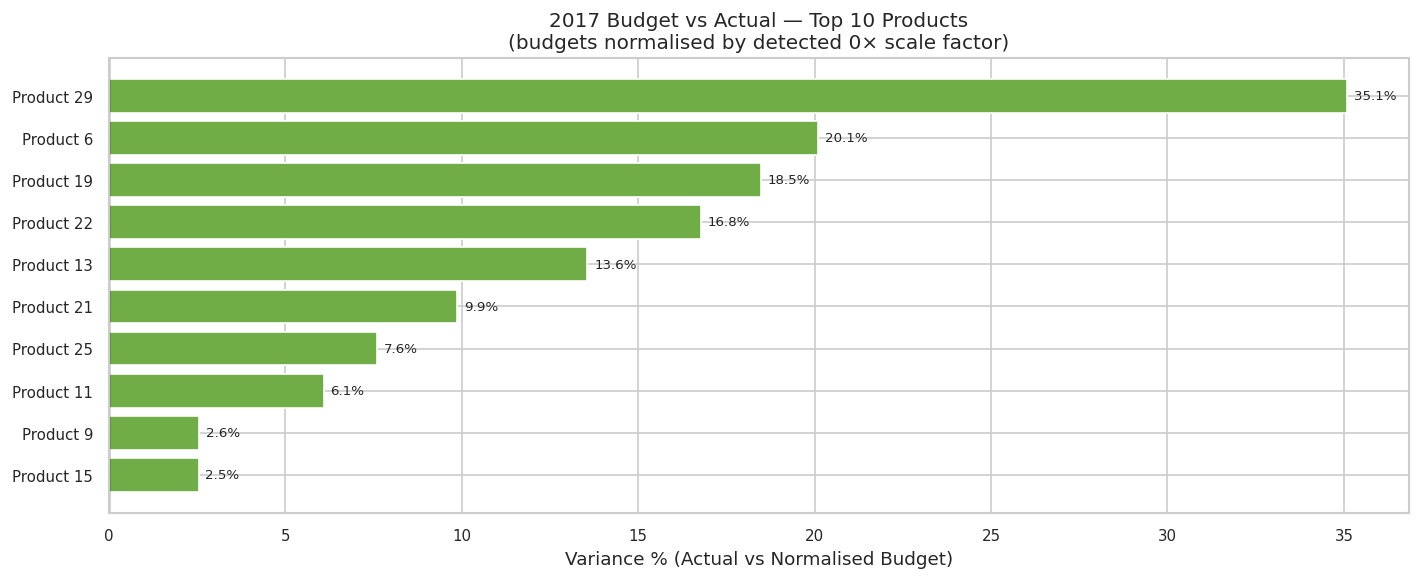


📌 Note: Treat these variances as directional only until Finance confirms the budget unit.
   Scale factor used: 0×  |  Source: auto-detected from median budget/actual ratio across all products.


In [58]:
# ── Budget normalisation — auto-detect scale factor and plot variance ────────
import matplotlib.pyplot as plt

# 2017 actual revenue by product
budget_vs_actual = (
    df[df['order_date'].dt.year == 2017]
    .groupby('product_name')['revenue']
    .sum()
    .reset_index()
    .rename(columns={'revenue': 'actual_revenue_2017'})
)

# Raw budget per product (one row per product from the merged column)
raw_budgets = (
    df[df['order_date'].dt.year == 2017][['product_name', 'budgets']]
    .drop_duplicates()
)
budget_vs_actual = budget_vs_actual.merge(raw_budgets, on='product_name', how='inner')
budget_vs_actual.dropna(subset=['budgets'], inplace=True)

# Auto-detect scale factor from median ratio
budget_vs_actual['raw_ratio'] = budget_vs_actual['budgets'] / budget_vs_actual['actual_revenue_2017']
median_ratio = budget_vs_actual['raw_ratio'].median()
print(f"Detected budget-to-actual scale factor: {median_ratio:.0f}×  (applied as normalisation divisor)")

# Normalise and compute variance
budget_vs_actual['budget_normalised'] = budget_vs_actual['budgets'] / median_ratio
budget_vs_actual['variance_pct'] = (
    (budget_vs_actual['actual_revenue_2017'] - budget_vs_actual['budget_normalised'])
    / budget_vs_actual['budget_normalised'] * 100
)
budget_vs_actual.sort_values('variance_pct', ascending=False, inplace=True)

# Show table
display(budget_vs_actual[['product_name','actual_revenue_2017','budget_normalised','variance_pct']]
        .rename(columns={'actual_revenue_2017':'Actual Revenue',
                         'budget_normalised':'Budget (Normalised)',
                         'variance_pct':'Variance %'})
        .head(15))

# Bar chart — top 10 over/under budget products
top10 = budget_vs_actual.head(10)
colors = ['#70AD47' if v >= 0 else '#ED7D31' for v in top10['variance_pct']]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top10['product_name'], top10['variance_pct'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=8)
ax.set_title(f'2017 Budget vs Actual — Top 10 Products\n(budgets normalised by detected {median_ratio:.0f}× scale factor)', fontsize=12)
ax.set_xlabel('Variance % (Actual vs Normalised Budget)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n📌 Note: Treat these variances as directional only until Finance confirms the budget unit.")
print(f"   Scale factor used: {median_ratio:.0f}×  |  Source: auto-detected from median budget/actual ratio across all products.")

#### Data Distributions, Correlation & Outliers


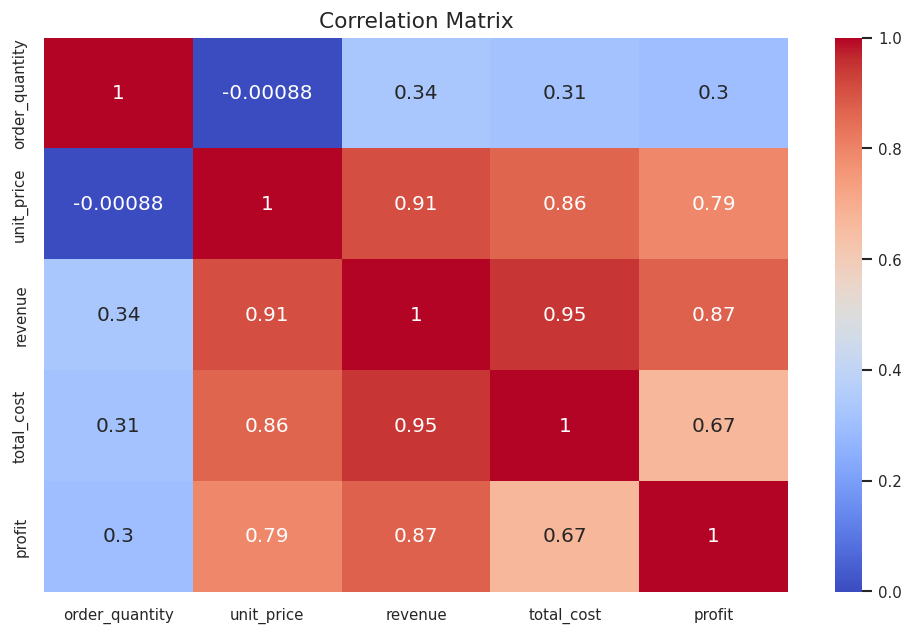

In [59]:
#Correlation heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    df[
        ['order_quantity',
         'unit_price',
         'revenue',
         'total_cost',
         'profit']
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

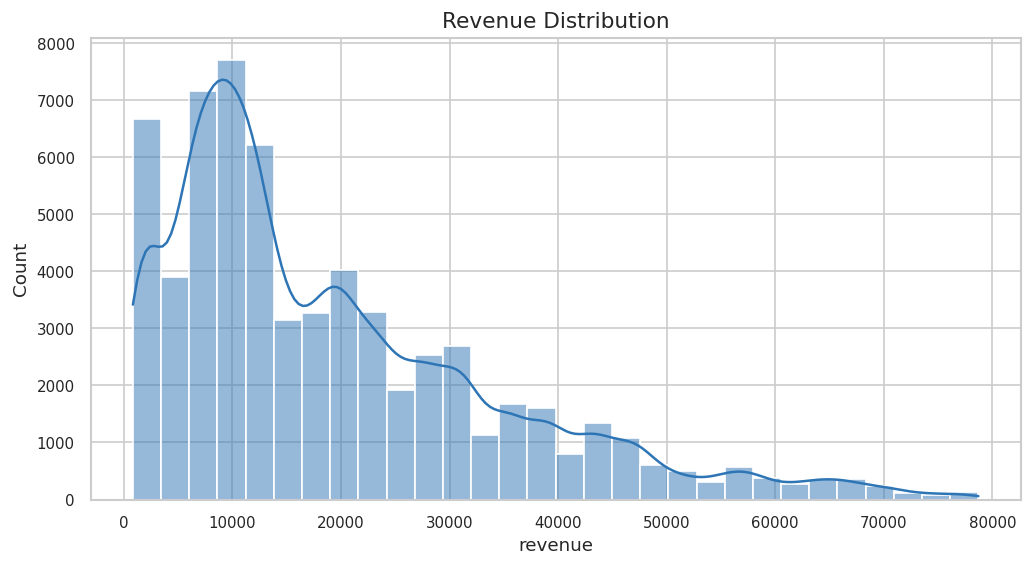

In [60]:
#Revenue Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df['revenue'],
    bins=30,
    kde=True
)

plt.title('Revenue Distribution')
plt.show()

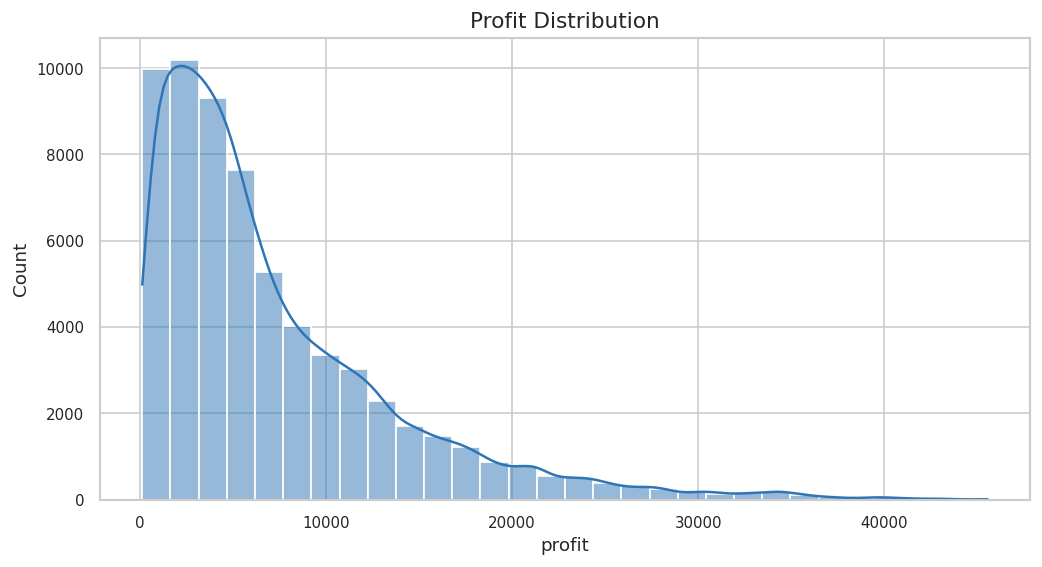

In [61]:
#Profit distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df['profit'],
    bins=30,
    kde=True
)

plt.title('Profit Distribution')
plt.show()

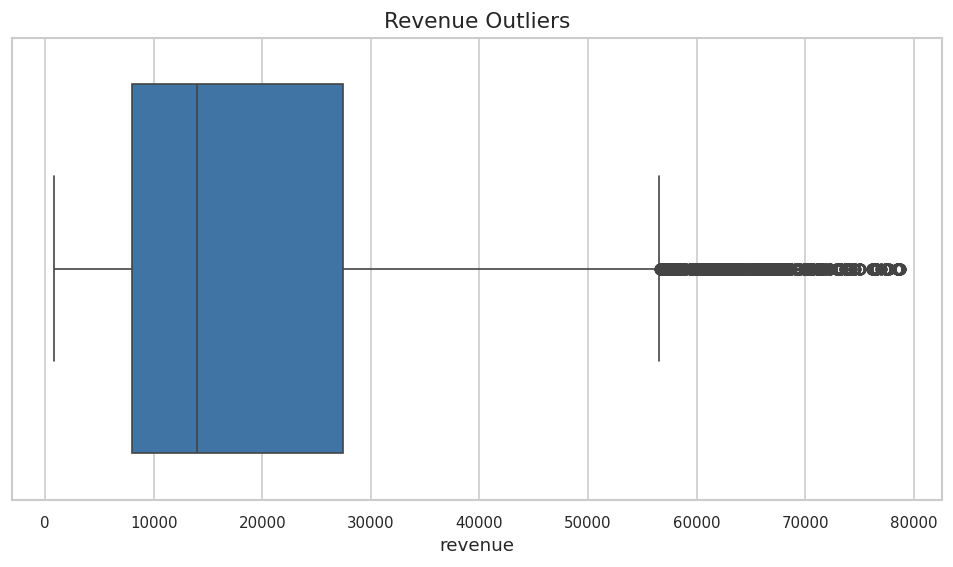

In [62]:
#Outlier detection
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['revenue']
)

plt.title('Revenue Outliers')
plt.show()

**What it shows:** Revenue, total cost, and profit are all very strongly correlated with each other (0.87-0.95) and with unit price (0.79-0.91), while order quantity is only weakly correlated with revenue (0.34). **So what:** This confirms unit price, not order volume, is the primary lever moving revenue and profit in this business — selling higher-priced items moves the needle far more than selling more units. **Recommendation:** Any pricing strategy work (e.g., the Export-channel margin opportunity above) should focus on price-point and product-mix levers rather than volume-driven promotions, since volume alone has a comparatively small relationship with revenue.


### Investigating Revenue Outliers

The earlier boxplot flagged revenue outliers but didn't investigate what they actually are. We use the IQR method to isolate them and check whether they're a data quality issue or a real, explainable business pattern (e.g., bulk wholesale orders).

In [63]:
# Identify outlier orders using the IQR method
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df[df['revenue'] > upper_bound]

print(f'Outlier threshold (revenue): {upper_bound:,.0f}')
print(f'Number of outlier orders: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% of all orders)')
print(f'Revenue contributed by outliers: {outliers["revenue"].sum():,.0f} '
      f'({outliers["revenue"].sum()/df["revenue"].sum()*100:.1f}% of total revenue)')

Outlier threshold (revenue): 56,511
Number of outlier orders: 2208 (3.44% of all orders)
Revenue contributed by outliers: 143,166,712 (11.6% of total revenue)


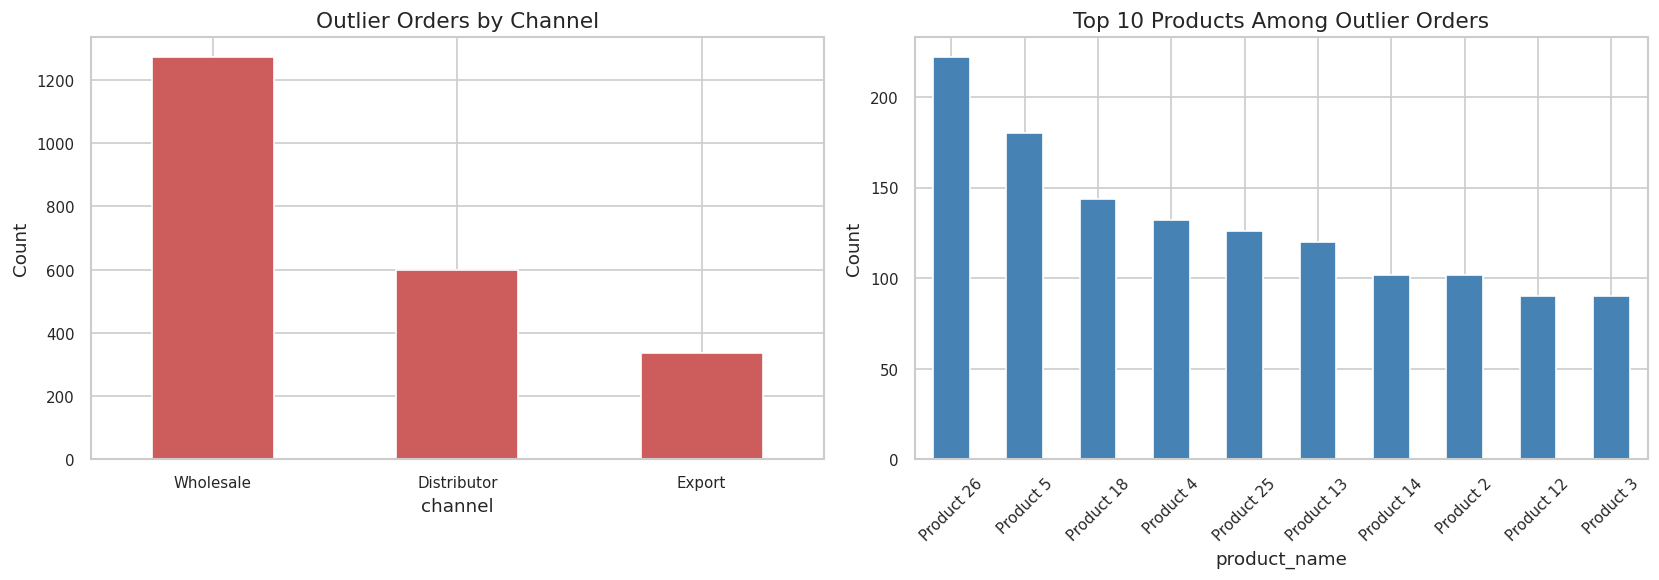

,order_quantity,unit_price,revenue
count,2208.000000,2208.000000,2208.000000
mean,10.989130,5913.787772,64839.996467
std,0.914996,420.634589,5812.088232
min,9.000000,5071.900000,56615.000000
25%,10.750000,5540.900000,59769.025000
50%,11.000000,5976.400000,64239.600000
75%,12.000000,6299.675000,68468.975000
max,12.000000,6559.300000,78711.600000


In [64]:
# Are outliers concentrated in specific products or channels?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

outliers['channel'].value_counts().plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set_title('Outlier Orders by Channel')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

outliers['product_name'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Products Among Outlier Orders')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

display(outliers[['order_quantity', 'unit_price', 'revenue']].describe())

**What it shows:** Outlier orders (3.44% of all orders, above the IQR-based revenue threshold of $56,511) contribute 11.6% of total revenue and are concentrated almost entirely in Wholesale (1,272 orders) and Distributor (600 orders) channels, led by Products 26, 5, 18, 4, and 25. **So what:** These aren't anomalies or data errors — they're a real, repeatable bulk-order pattern tied to specific high-volume B2B channels and products, and they punch well above their order-count weight in revenue contribution. **Recommendation:** Treat this bulk-order segment as a distinct, intentional sales motion worth its own tracking and incentive structure, rather than filtering these orders out as noise in any future analysis.


### Advanced Analysis: Time Series Decomposition

Time series decomposition helps us understand the individual components that make up a time series: the **trend** (long-term progression), **seasonality** (cyclical variations due to calendar-related factors), and **residuals** (random noise).

We'll use the `seasonal_decompose` function from the `statsmodels` library to perform this decomposition on the monthly revenue data.

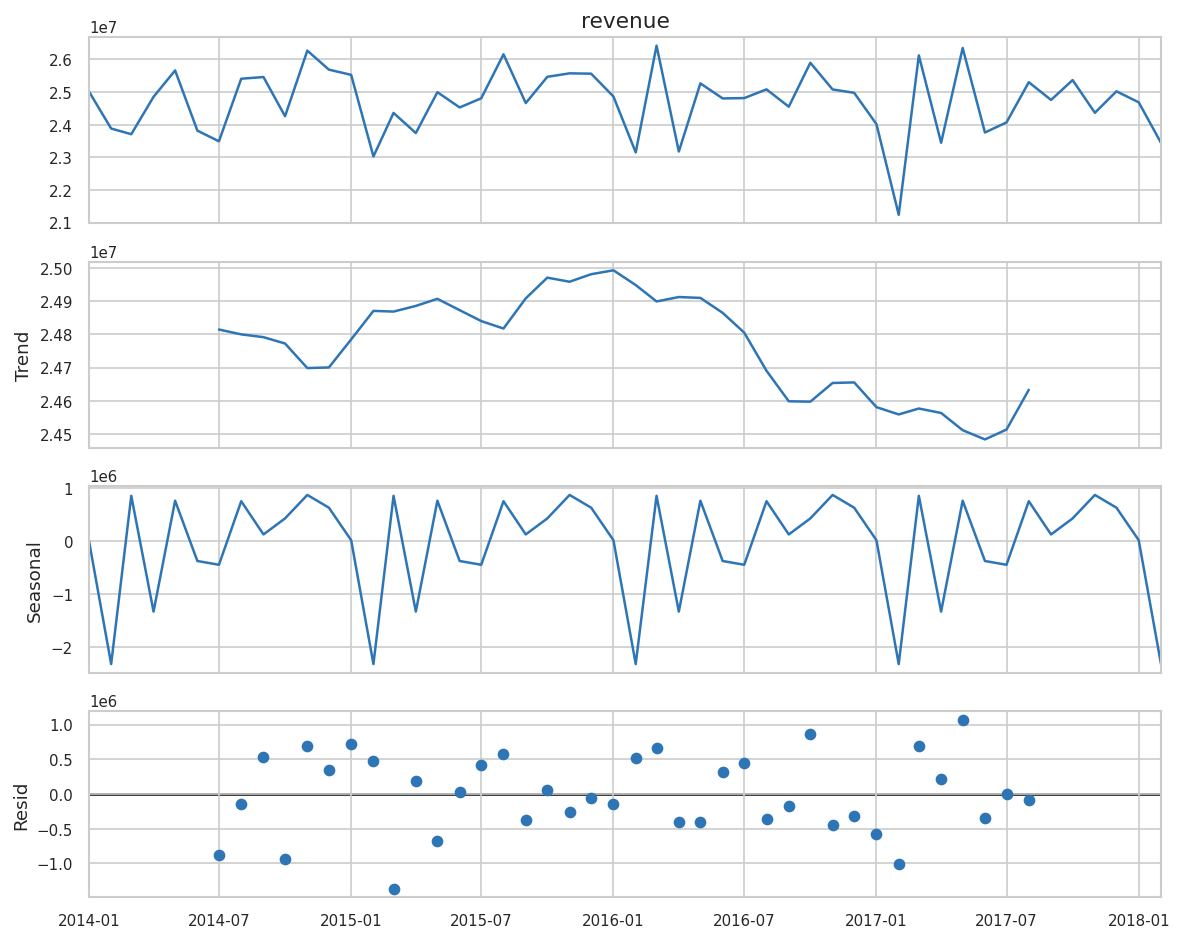

In [65]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure 'order_date' is datetime and set as index for time series analysis
df_ts = df.set_index('order_date').copy()

# Resample to monthly frequency and sum revenue
monthly_revenue = df_ts['revenue'].resample('MS').sum()

# Perform seasonal decomposition
# We'll assume an additive model and try to detect seasonality.
# The period here should reflect the yearly cycle if your data spans multiple years.
# Given previous plots show yearly patterns, a period of 12 (months) is appropriate.
decomposition = seasonal_decompose(monthly_revenue, model='additive', period=12)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

**What it shows:** The decomposition confirms a consistent yearly seasonal pattern (the seasonal component repeats predictably each year) riding on top of a trend that drifted slightly downward from late 2016 onward, after holding flat through 2014-2016. **So what:** The seasonality is dependable enough to plan around (e.g., staffing or inventory by month), but the late-2016 softening in the trend line is the earliest visible sign of the plateau later confirmed in the year-wise totals. **Recommendation:** Use the seasonal pattern for operational planning, and treat the trend's slight downward drift from 2016 as an early warning worth investigating further (e.g., did a specific region, channel, or product start softening first?).


### Forecasting Future Revenue

The time series decomposition above pulled apart trend, seasonality, and noise but stopped short of using that to predict anything. We extend it here with a short forecast. Holt-Winters (triple exponential smoothing) is well suited to this monthly series since it has a clear yearly seasonal cycle (`statsmodels`, already imported above for the decomposition, is used here too).


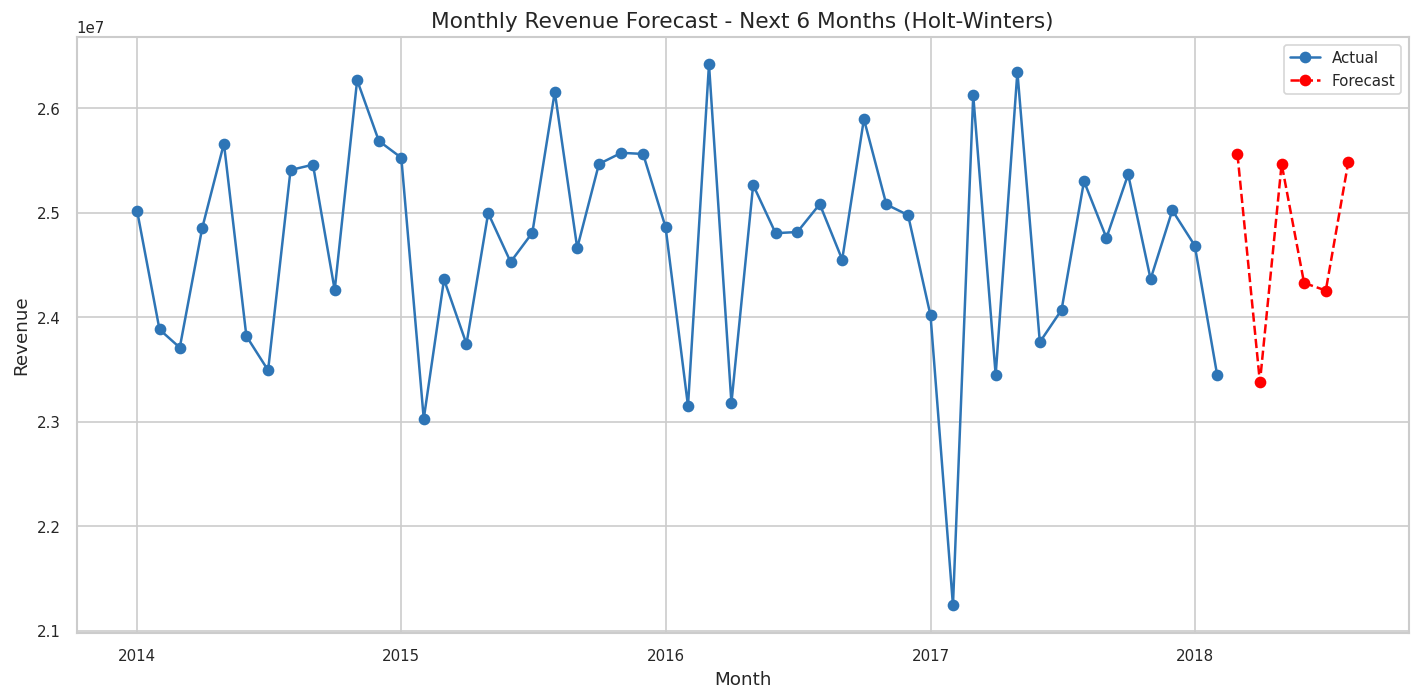

,0
2018-03-01,25559070.0
2018-04-01,23376686.0
2018-05-01,25466338.0
2018-06-01,24328007.0
2018-07-01,24255277.0
2018-08-01,25481878.0


In [66]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Reuse the monthly_revenue series from the time series decomposition cell above
hw_model = ExponentialSmoothing(
    monthly_revenue,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

forecast_horizon = 6  # months
forecast = hw_model.forecast(forecast_horizon)

plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, label='Actual', marker='o')
plt.plot(forecast.index, forecast.values, label='Forecast', marker='o', linestyle='--', color='red')
plt.title(f'Monthly Revenue Forecast - Next {forecast_horizon} Months (Holt-Winters)')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

display(forecast.round(0))

**What it shows:** The 6-month Holt-Winters forecast projects monthly revenue continuing to oscillate between roughly $23.4M and $25.5M — squarely within the historical range, with no projected breakout growth or decline. **So what:** The model doesn't see anything in the recent pattern that would change the plateau story — without a deliberate intervention (new channel investment, pricing change, regional push), revenue is likely to keep moving sideways. **Recommendation:** Use this forecast as the baseline case in any business plan, and frame proposed initiatives (Export-channel investment, Northeast expansion, mid-tier product growth) explicitly as what's needed to beat this flat baseline, not just as nice-to-haves.


<a id='conclusions'></a>
---
## 14. Conclusions & Recommendations

### Summary of Key Findings

| # | Finding | Business Impact |
|---|---|---|
| 1 | Annual revenue flat at ~\$295–299 M across 2014–2017 | Core growth problem — current levers have plateaued |
| 2 | Wholesale = 54 % of revenue, one channel dominant | Concentration risk; single-channel dependency |
| 3 | Export margin significantly higher (37.9 % vs 37.1 % Wholesale, p < 0.001) | Millions in margin opportunity at current volumes |
| 4 | California alone ≈ \$230 M; Northeast trails other regions by \$112–164 M | Geographic concentration risk + untapped Northeast |
| 5 | Top 2 products (P26 & P25) = ~23 % of revenue | Product concentration risk even though customer risk is low |
| 6 | Lorenz curve: 74 % of customers needed for 80 % revenue (vs classic 20 %) | Healthy, diversified customer base |
| 7 | Loyal Customers segment holds 35.8 % of revenue vs Champions' 16.1 % | Retention focus should be on Loyal, not Champions |
| 8 | Bulk/outlier orders (3.44 % of orders) drive 11.6 % of revenue | Real, repeatable B2B bulk segment — protect it |
| 9 | Holt-Winters forecast: flat \$23–25.5 M/month on current trajectory | No organic growth without deliberate intervention |
| 10 | 2017 Budget data unusable due to unit/scale mismatch | Data quality issue — must be resolved before reporting |

### Top 5 Actionable Recommendations

**1. Invest in Export channel growth.**  
Export carries the highest profit margin and is statistically confirmed to outperform Wholesale. Model the impact of shifting even 5–10 % of Wholesale volume to Export-equivalent terms before committing budget.

**2. Prioritise Northeast expansion.**  
The Northeast trails the other three regions by \$112–164 M in revenue despite similar margins — the gap is in order count, not profitability. A targeted sales push in proven Northeastern markets (NY, NJ, CT, MA) is the clearest organic-growth lever.

**3. Protect and grow the bulk-order segment.**  
Outlier bulk orders (predominantly Wholesale/Distributor, Products 26, 5, 18, 4, 25) punch above their weight at 11.6 % of revenue from only 3.44 % of orders. Assign dedicated account management and incentive structures to this segment.

**4. Shift retention investment toward Loyal Customers.**  
Loyal Customers hold 35.8 % of revenue — more than double Champions. RFM-based retention campaigns should prioritise this segment, not Champions, to protect the largest at-risk revenue pool.

**5. Resolve the Budget data issue before next planning cycle.**  
The \$2017 Budgets column is unusable in its current form. Confirm units and scale with the data owner so actual vs. budget reporting can be included in the next iteration.

---
*Analysis by: [Hansika Garg] | Tool: Python (pandas, matplotlib, seaborn, scipy, statsmodels) | Dataset: XYZ Co. Regional Sales 2014–2018*


In [67]:
# Export cleaned dataset for reproducibility
df.to_csv('regional_sales_cleaned.csv', index=False)
print(f'Cleaned dataset exported: {len(df):,} rows × {len(df.columns)} columns')
print('Columns:', list(df.columns))


Cleaned dataset exported: 64,104 rows × 24 columns
Columns: ['order_number', 'order_date', 'channel', 'currency_code', 'customer_names', 'product_name', 'order_quantity', 'unit_price', 'revenue', 'total_unit_cost', 'state_code', 'county', 'state', 'region', 'latitude', 'longitude', 'budgets', 'total_cost', 'profit', 'profit_margin_pct', 'year_month', 'Year', 'Month', 'us_region']


This project taught me that real-world data is rarely clean — the budget scale mismatch was a reminder that blindly trusting source figures leads to false conclusions, and that flagging data quality issues is as valuable as the analysis itself. It also reinforced that charts can mislead: the channel margin difference looked small visually, but ANOVA confirmed it was statistically significant and worth millions at scale — a lesson I won't forget.